# Personal Loan Campaign
## Case Study - Mads Schmidt Petersen



## Problem Statement

### Context

AllLife Bank is a mid-sized, fast-growing US-based financial institution that offers a range of retail banking services, including savings and checking accounts, fixed deposits, and personal loans. The bank’s business model is centered on building long-term customer relationships, expanding its retail footprint, and growing its loan portfolio to drive sustainable profitability through interest income.

It currently relies on a large base of liability customers (depositors) but faces a significant under-representation of asset customers (borrowers). To drive profitability through interest income, the bank must aggressively expand its loan portfolio by converting existing depositors into personal loan customers.

Last year’s pilot campaign achieved a 9% conversion rate, validating the potential of this strategy. However, to optimize marketing spend and improve efficiency, the retail marketing department requires a more data-driven approach. Enhancing the success ratio of these campaigns is critical for sustainable growth and maximizing customer lifetime value.

### Objective

The objective is to develop a predictive classification model that identifies patterns and key factors driving personal loan adoption among existing liability customers. By uncovering the demographic and behavioral drivers of loan conversion, the goal is to enable targeted segmentation and more precise marketing interventions that improve campaign conversion rates, optimize marketing spend, and enhance overall profitability through higher-quality loan portfolio growth.

### Data Dictionary

* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 sklearn-pandas==2.2.0 -q --user

In [2]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Library for US Zip Codes
!pip install uszipcode -q --user

# Libraries for scaling numerical features
from sklearn.preprocessing import StandardScaler

# to perform k-means clustering
from sklearn.cluster import KMeans

# to perform silhouette analysis
from sklearn.metrics import silhouette_score

# to perform t-SNE
from sklearn.manifold import TSNE

# to define a common seed value to be used throughout
RS=0

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 2.3 MB/s eta 0:00:00


## Loading the dataset

In [3]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
Loan_Modelling_Data = pd.read_csv('/content/drive/My Drive/MKBSP Case Studies/Personal Loan Campaign/Loan_Modelling.csv')

In [5]:
# creating a copy of the data
data = Loan_Modelling_Data.copy()

## Data Overview

### Checking the shape of the dataset.

In [6]:
data.shape

(5000, 14)

The data has 5000 rows, and 14 columns.

### Viewing the first and last 5 rows of the dataset

In [7]:
data.head(5)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [8]:
data.tail(5)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


Based on the data.head() and data.tail() outputs, and cross-referencing with the data dictionary, everything appears to be in order. The values for each column seem to fall within expected ranges and formats, and there are no immediate signs of data corruption or glaring inconsistencies.

### Checking the attribute types

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


**Non-null instances:**

0 non-null instances

**Data types:**

All but CCAvg is a **float**, all others are **integers**.

### Checking the statistical summary

In [10]:
data.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


#### Immediate Statistical Observations

*   **Age**: The average age of customers is 45 years, ranging from 23 to 67.
*   **Experience**: On average, customers have 20 years of experience, with a maximum of 43 years. The presence of a minimum experience of -3 years is unusual and should be addressed during data cleaning, as it likely represents a data entry error or a specific category not clearly defined.
*   **Income**: The average annual income is 73,774, with a wide range from $8,000 to 224,000.
*   **CCAvg**: The average monthly credit card spending is 1,938, varying from 0 to 10,000.
*   **Mortgage**: The average mortgage value is 56,499. However, the minimum and 25th percentile values are 0, while the maximum is 635,000. This indicates a significant portion of customers have no mortgage, and those who do, have a widely distributed range, suggesting a skewed distribution with potential outliers or high-value mortgages.

#### Key Categorical and Binary Feature Observations:

1.  **Education**: The median education level is 2 (Graduate), and the mean is 1.88, indicating that a significant portion of the customer base holds a graduate degree or higher, suggesting a well-educated group.
2.  **Personal Loan Adoption**: Only about 9.6% of customers (0.096 mean) accepted the personal loan offer in the last campaign, highlighting the low conversion rate.
3.  **Securities Account**: Approximately 10.4% of customers (0.1044 mean) have a securities account with the bank.
4.  **CD Account**: A smaller percentage, about 6% of customers (0.0604 mean), possess a Certificate of Deposit (CD) account.
5.  **Online Banking**: A substantial majority, nearly 60% of customers (0.5968 mean), utilize online banking facilities.
6.  **Credit Card (Other Banks)**: Around 29.4% of customers (0.2940 mean) hold a credit card issued by another bank.

### Checking for missing values

In [11]:
# checking for null values
data.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


- There are no missing values in the data.

### Checking for duplicate values

In [12]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

* There are no duplicate values in the data.

## Exploratory Data Analysis.

### Univariate Analysis

Univariate analysis helps us understand the distribution of individual variables. We'll start by visualizing the numerical features using histograms and then move on to categorical/binary features using count plots. We will exclude `ID` and `ZIPCode` from these general distribution plots as their individual values are not typically analyzed in this manner; `ID` is a unique identifier, and `ZIPCode` is a geographical identifier better suited for spatial analysis or treated as a categorical variable.

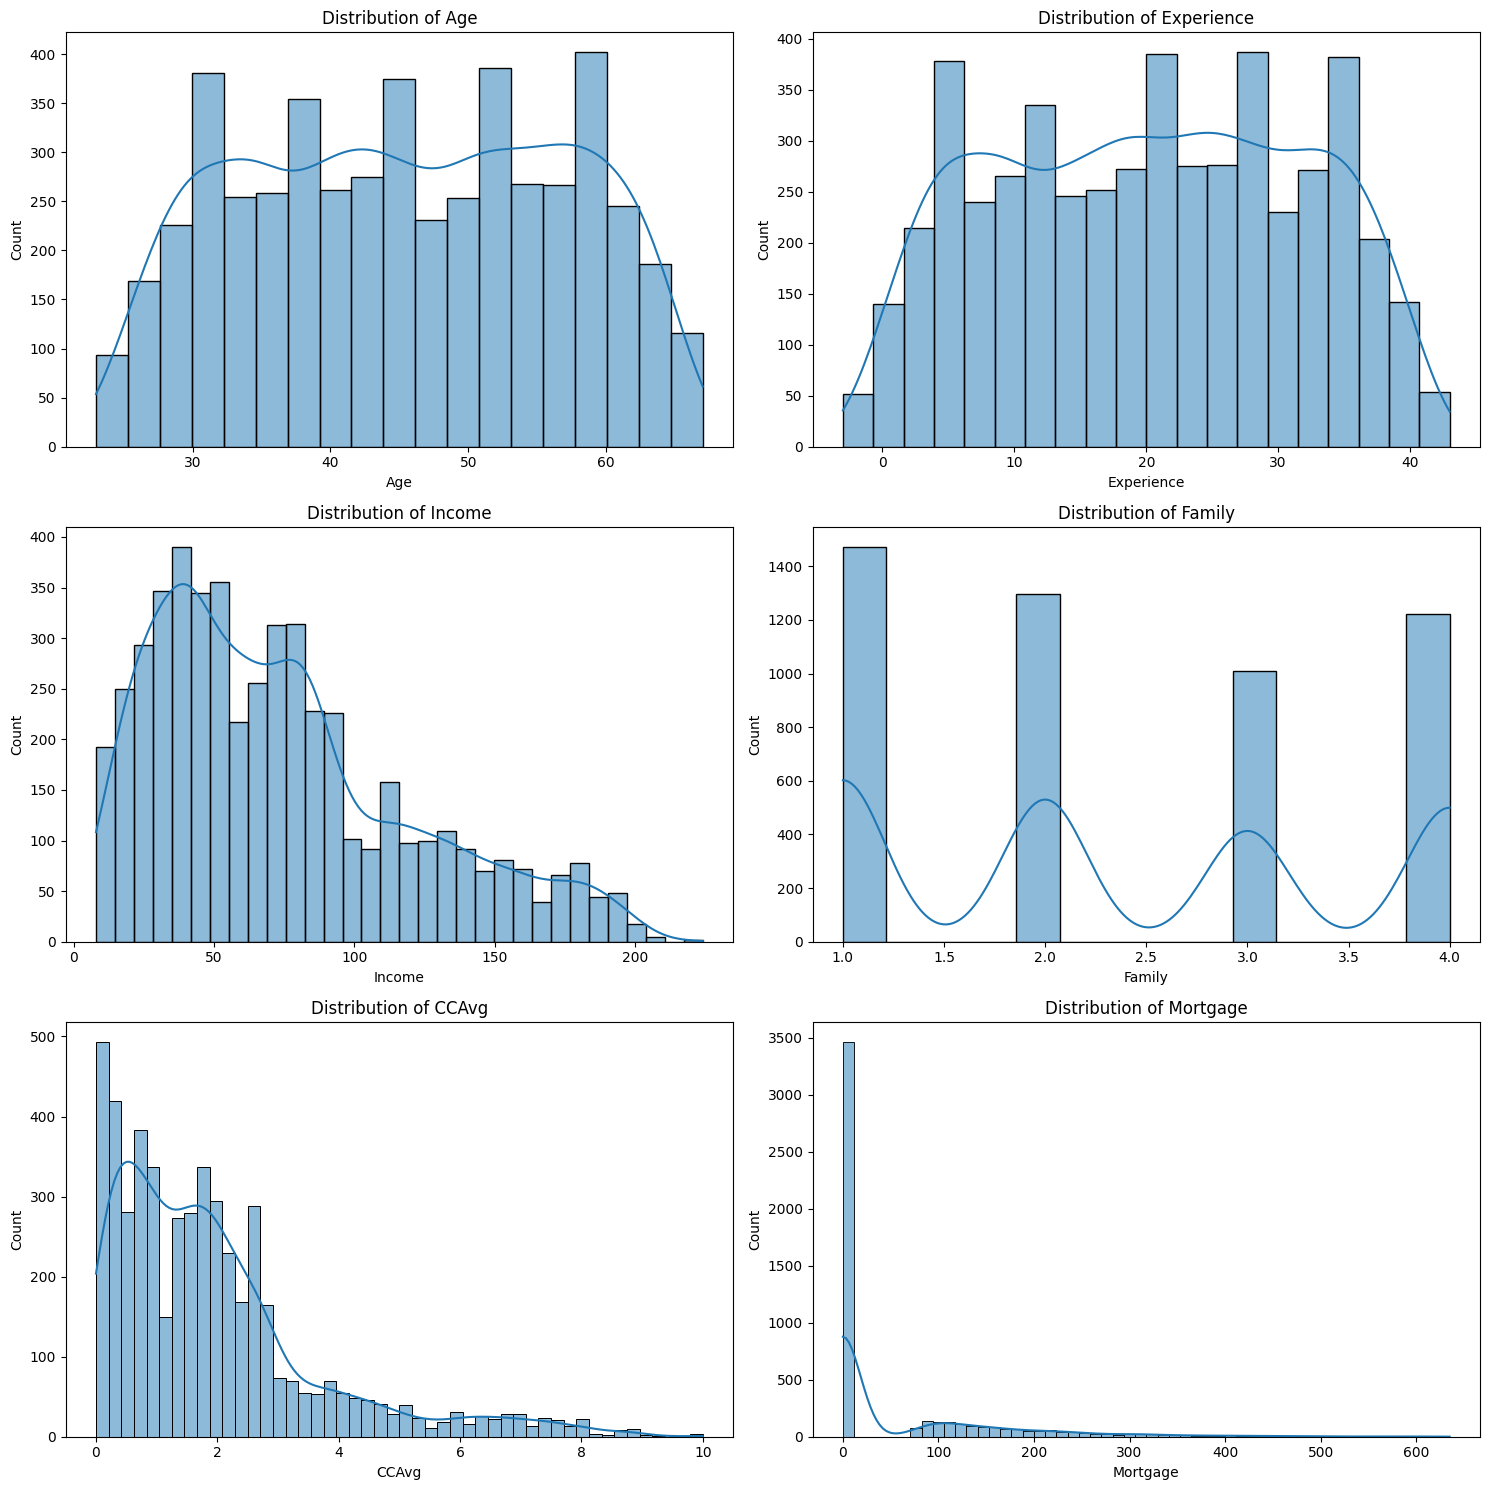

In [13]:
# Identify numerical features for histograms
numerical_features = ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Mortgage']

# Set up the figure and axes for numerical features
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten() # Flatten the 3x2 array of axes for easy iteration

# Plot histograms for each numerical feature
for i, feature in enumerate(numerical_features):
    sns.histplot(data=data, x=feature, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

Next, let's visualize the distribution of categorical and binary features using count plots. These plots show the frequency of each category within a variable.

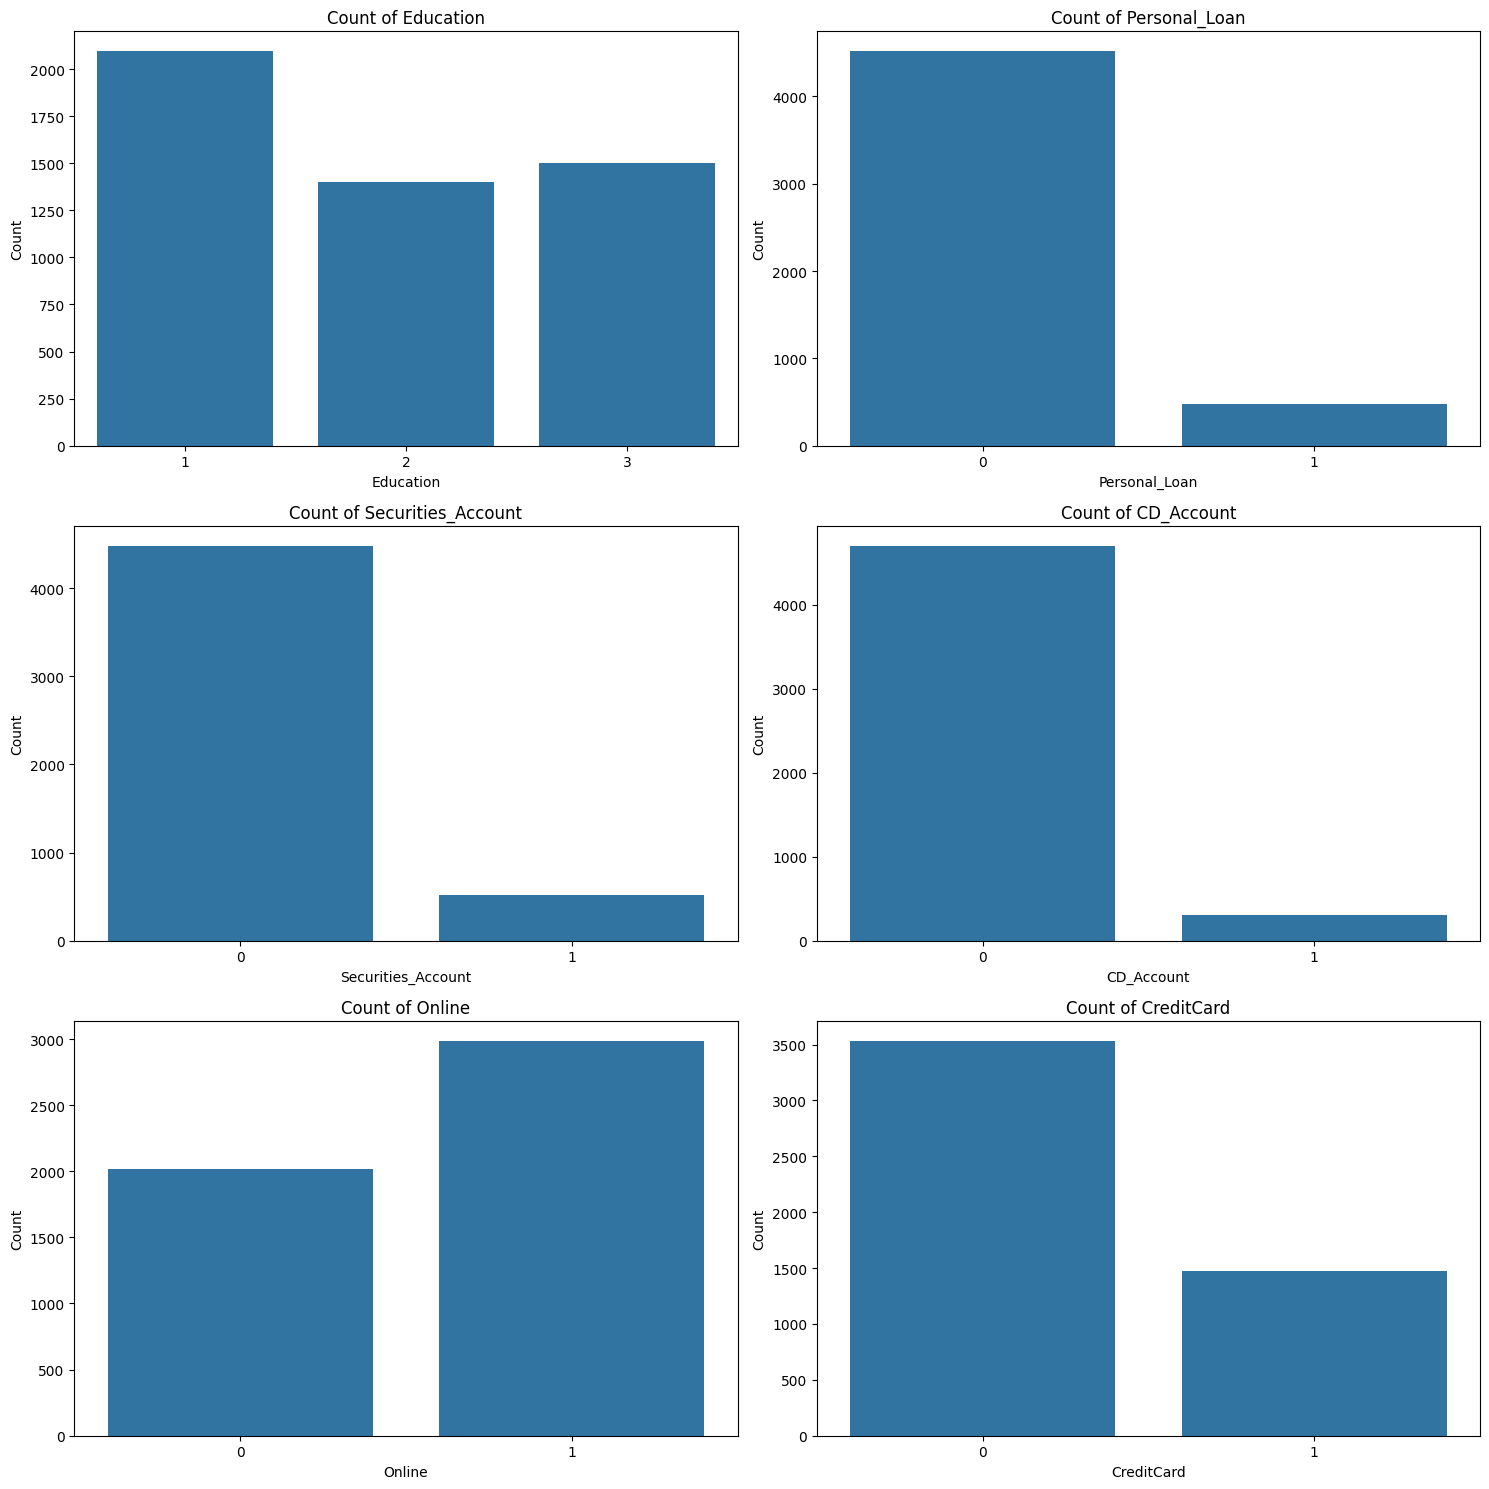

In [14]:
# Identify categorical/binary features for count plots
categorical_features = ['Education', 'Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard']

# Set up the figure and axes for categorical features
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten() # Flatten the 3x2 array of axes for easy iteration

# Plot count plots for each categorical feature
for i, feature in enumerate(categorical_features):
    sns.countplot(data=data, x=feature, ax=axes[i])
    axes[i].set_title(f'Count of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

Thoughts

### Bivariate Analysis

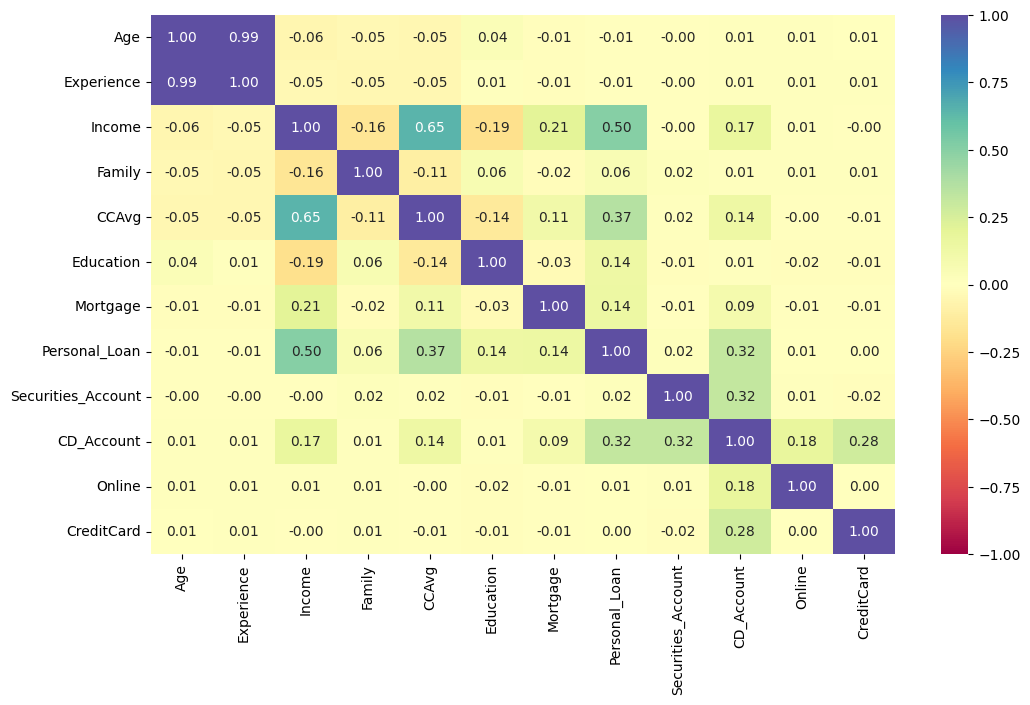

In [15]:
plt.figure(figsize=(12, 7))
sns.heatmap(
    data.drop(columns=['ID', 'ZIPCode']).corr(),
    annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

Looking away from Age / Experience correlation, our best connected features are:

- CCAvg / Income = 0.65
- Personal Loan / Income = 0.50
- Personal Loan / CCAvg = 0.37
- Personal Loan / CD Account = 0.32
- CD Account / Securities Account = 0.32
- CreditCard / CD Account = 0.28
- Income / Mortgage = 0.21
- Education / Income = -0.19
- Online / CD Account = 0.18
- CD Accont / Income = 0.17
- Personal Loan / Education = 0.14
- Personal Loan / Mortgage = 0.14
- Education / CCAvg = -0.14
- CCAvg / Mortgage = 0.11
- Family / CCAvg = -0.11

What most interesting for us is everything that is impacting Personal Loan:
- Personal Loan / Income = 0.50
- Personal Loan / CCAvg = 0.37
- Personal Loan / CD Account = 0.32
- Personal Loan / Education = 0.14
- Personal Loan / Mortgage = 0.14



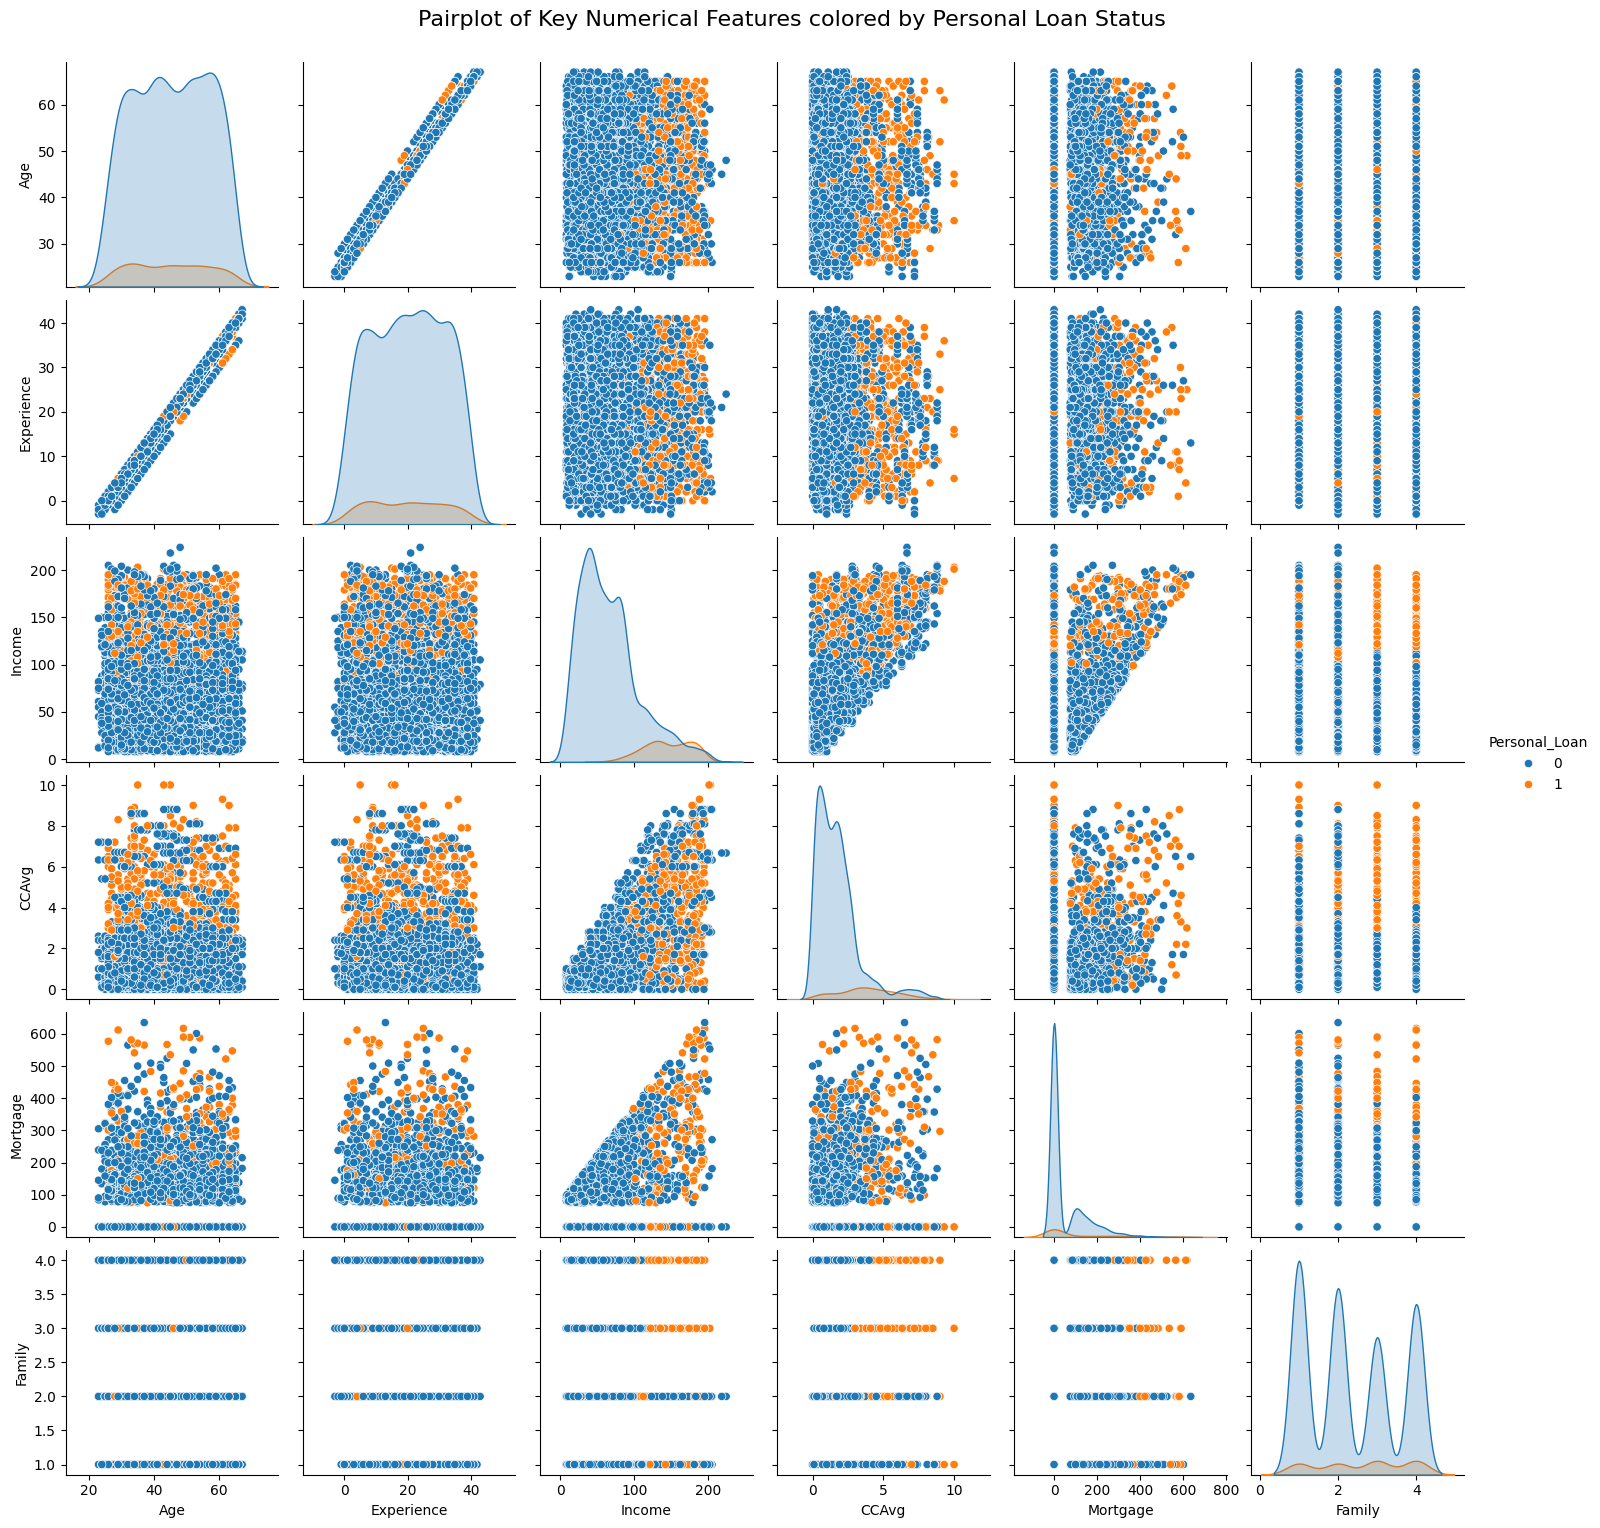

In [16]:
# Select relevant features for the pairplot, including the target variable
# Exclude ID and ZIPCode, and other binary/categorical features better suited for count plots or specific analyses
relevant_features = ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage', 'Family', 'Personal_Loan']

sns.pairplot(data[relevant_features], hue='Personal_Loan', diag_kind='kde');
plt.suptitle('Pairplot of Key Numerical Features colored by Personal Loan Status', y=1.02, fontsize=16)
plt.show()

It looks like these Combinations have high correlation with Accepted Personal Loans:
- Income above 100K + Family 3+
- Mortgage above 300K + Family 3+
- CCAvge above 4 + Large Family 3+

Low income is always resulting in Personal Loans not accepted.


**Income >100K + Family >= 3:** Is a strong predictor. A clear cluster of accepted loans  at from users with high income levels combined with family sizes of 3-4.

**Mortgage >300K + Family >= 3:** Mortgage alone is weak, but this combination matters. Higher mortgage + larger family noticeably increases acceptance likelihood.

**CCAvg >4K + Family >= 3:** High spend + larger family correlates strongly with acceptance. The "Yes" group clusters visibly in the upper CCAvg range.

**Low income = almost never accepted:** Consistent across all plots. Income appears to be a hard threshold, not just a factor.

---

### Initial Questions to Answer:

#### 1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?

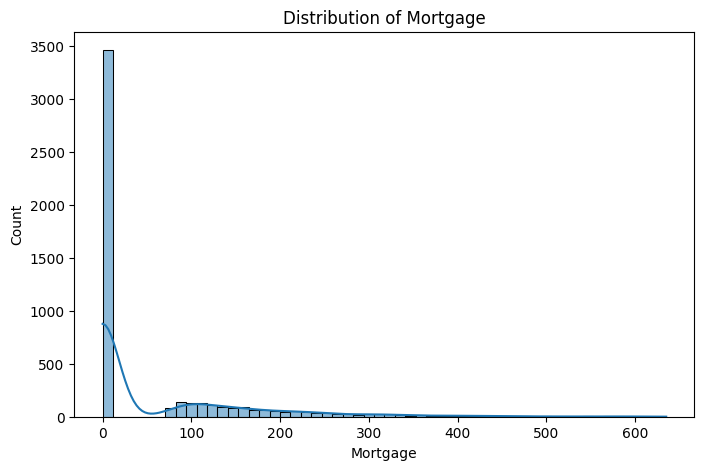

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=data, x='Mortgage', kde=True, ax=ax)
ax.set_title('Distribution of Mortgage')
plt.show()

In [18]:
no_mort = (data['Mortgage'] == 0).sum()
has_mort = (data['Mortgage'] > 0).sum()
pct_no = no_mort / len(data) * 100

print(f"Users with no mortgage: {no_mort}")
print(f"Users with mortgage: {has_mort}")
print(f"Percentage of users without a mortgage: {pct_no:.1f}%")

Users with no mortgage: 3462
Users with mortgage: 1538
Percentage of users without a mortgage: 69.2%


The vast majority of people have no mortgage, which is evident from this right skewed distribution. 69.2% of users have 0 USD in mortgage, meaning they have no mortgage.

The average mortgage value is 56,499. However, the minimum and 25th percentile values are 0, while the maximum is 635,000. Those who do have a mortgate, have a widely distributed range, suggesting a skewed distribution with potential outliers or high-value mortgages.



What does this analysis look like WITHOUT the users who have no mortgage:

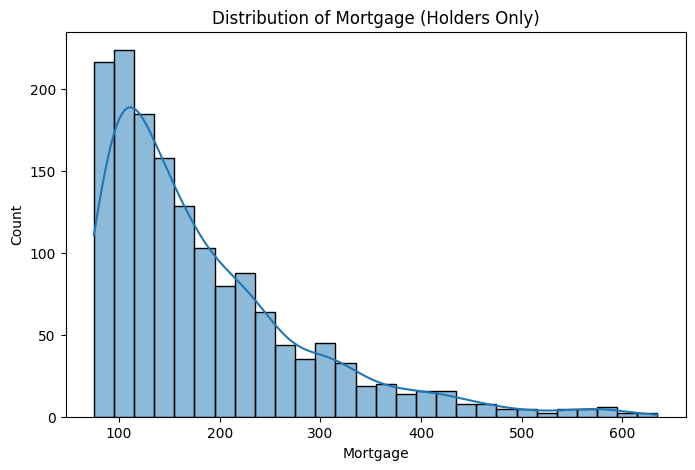

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=data[data['Mortgage'] > 0], x='Mortgage', kde=True, ax=ax)
ax.set_title('Distribution of Mortgage (Holders Only)')
plt.show()

count    1538.000000
mean      183.676203
std       101.361226
min        75.000000
25%       109.000000
50%       153.000000
75%       227.000000
max       635.000000
Name: Mortgage, dtype: float64
Mean: 184
Median: 153
Mode: [98]


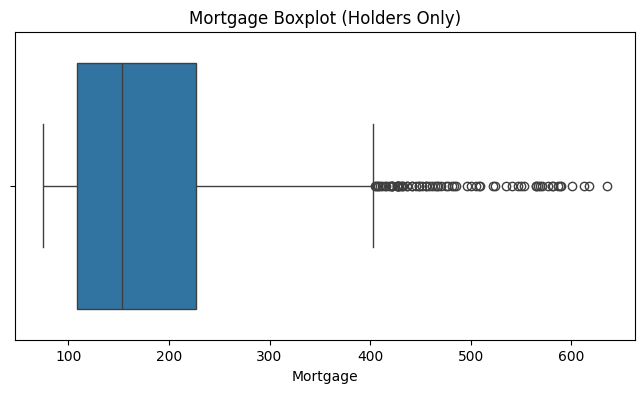

In [20]:
mort = data[data['Mortgage'] > 0]['Mortgage']

# Stats
print(mort.describe())
print(f"Mean: {mort.mean():.0f}")
print(f"Median: {mort.median():.0f}")
print(f"Mode: {mort.mode().values}")

# Boxplot
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=mort, ax=ax)
ax.set_title('Mortgage Boxplot (Holders Only)')
plt.show()

This statistical analysis shows, Average Mortgage, of people who have a mortgage, is 184. Our boxplot tops at 400, and we have a lot of outliers!

#### 2. How many customers have credit cards?


In [49]:
no_cc = (data['CCAvg'] == 0).sum()
has_cc = (data['CCAvg'] > 0).sum()
pct_no = has_cc / len(data) * 100

print(f"Users with no Credit Card: {no_cc}")
print(f"Users with Credit Card: {has_cc}")
print(f"Percentage of users with a Credit Card: {pct_no:.1f}%")

Users with no Credit Card: 106
Users with Credit Card: 4894
Percentage of users with a Credit Card: 97.9%


4894 (97.9%) of customers show credit card spending. `CCAvg > 0` serves as a proxy for credit card ownership in this analysis.

Customers with `CCAvg = 0` are cross-referenced with their `CreditCard` status.

In [22]:
no_ccavg_users = data[data['CCAvg'] == 0]

creditcard_status_no_ccavg = no_ccavg_users['CreditCard'].value_counts(normalize=True) * 100

print("Credit Card Status for users with no Credit Card Average spending (CCAvg == 0):")
print(creditcard_status_no_ccavg)

print(f"\nNumber of users with no CCAvg and no CreditCard from other bank: {no_ccavg_users['CreditCard'].value_counts().get(0, 0)}")
print(f"Number of users with no CCAvg but have CreditCard from other bank: {no_ccavg_users['CreditCard'].value_counts().get(1, 0)}")

Credit Card Status for users with no Credit Card Average spending (CCAvg == 0):
CreditCard
0    73.584906
1    26.415094
Name: proportion, dtype: float64

Number of users with no CCAvg and no CreditCard from other bank: 78
Number of users with no CCAvg but have CreditCard from other bank: 28


**4922 People have credit cards.**
We found that 4896 people had some credit spend from the banks data, and besides that, the remaining 106 people with 0 credit card spend, 28 had registered a credit card from another bank. Ie, total people with credit cards are estimated to be:


**4896 + 28 = 4922**


#### 3. What are the attributes that have a strong correlation with the target attribute (personal loan)?


- Income = 0.50
- CCAvg = 0.37
- CD Account = 0.32
- Education = 0.14
- Mortgage = 0.14

#### 4. How does a customer's interest in purchasing a loan vary with their education?

This correalation is weak, but, we can see that the higher the education level, the more likely they are in purchasing a loan.




Personal Loan Acceptance Rate by Education Level:
   Education  Personal_Loan  Personal_Loan_Acceptance_Rate (%)
0          1       0.044370                           4.437023
1          2       0.129722                          12.972202
2          3       0.136576                          13.657562


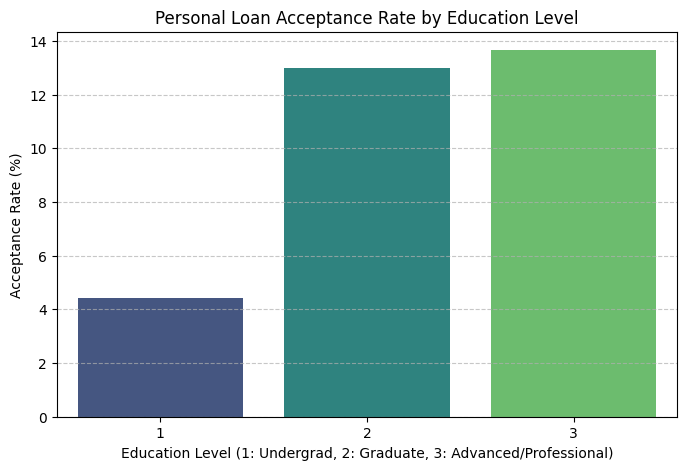

In [23]:
education_loan_acceptance = data.groupby('Education')['Personal_Loan'].mean().reset_index()
education_loan_acceptance['Personal_Loan_Acceptance_Rate (%)'] = education_loan_acceptance['Personal_Loan'] * 100

print("Personal Loan Acceptance Rate by Education Level:")
print(education_loan_acceptance)

# Visualize the acceptance rate
plt.figure(figsize=(8, 5))
sns.barplot(x='Education', y='Personal_Loan_Acceptance_Rate (%)', data=education_loan_acceptance, palette='viridis')
plt.title('Personal Loan Acceptance Rate by Education Level')
plt.xlabel('Education Level (1: Undergrad, 2: Graduate, 3: Advanced/Professional)')
plt.ylabel('Acceptance Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

As seen above, people with Advanced degrees are almost 3x as likely to purchase a loan compared to onhave ahving a bachelors degree.

#### 5. How does a customer's interest in purchasing a loan vary with their age?

Thers is pretty much NO correalation between age and purchasing a loan.

Personal Loan Acceptance Rate by Age Group:
  Age_Group  Personal_Loan  Personal_Loan_Acceptance_Rate (%)
0     20-29       0.100410                          10.040984
1     30-39       0.101844                          10.184443
2     40-49       0.093079                           9.307876
3     50-59       0.088456                           8.845577
4     60-69       0.102374                          10.237389


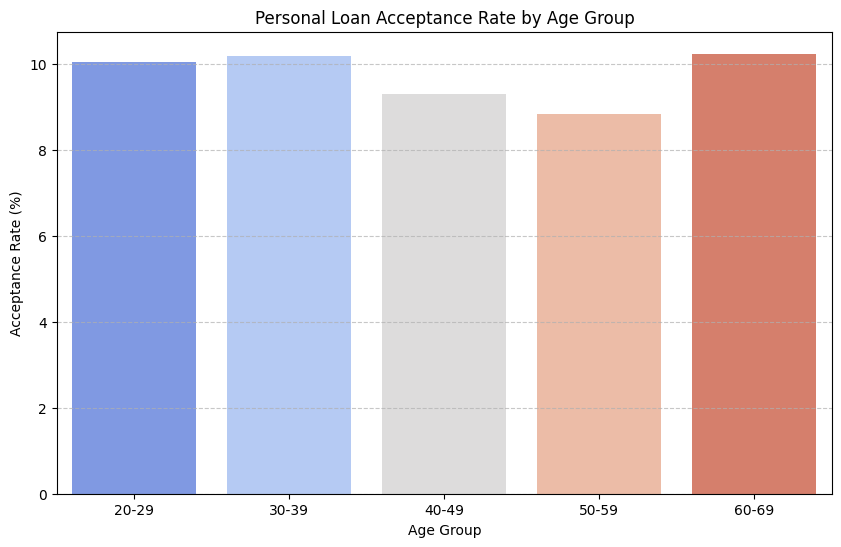

In [24]:
# Define age bins
age_bins = [20, 30, 40, 50, 60, 70]
age_labels = ['20-29', '30-39', '40-49', '50-59', '60-69']

# Create a new column 'Age_Group'
data['Age_Group'] = pd.cut(data['Age'], bins=age_bins, labels=age_labels, right=False)

# Calculate personal loan acceptance rate by age group
age_loan_acceptance = data.groupby('Age_Group')['Personal_Loan'].mean().reset_index()
age_loan_acceptance['Personal_Loan_Acceptance_Rate (%)'] = age_loan_acceptance['Personal_Loan'] * 100

print("Personal Loan Acceptance Rate by Age Group:")
print(age_loan_acceptance)

# Visualize the acceptance rate
plt.figure(figsize=(10, 6))
sns.barplot(x='Age_Group', y='Personal_Loan_Acceptance_Rate (%)', data=age_loan_acceptance, palette='coolwarm')
plt.title('Personal Loan Acceptance Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Acceptance Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Other EDA investigations

**Addressing the 'Experience' Anomaly:** We noted the minimum 'Experience' of -3 years. This could be a data quality issue.



Let's find out how many customers have a negative 'Experience' and what their `Personal_Loan` acceptance rate looks like compared to the overall average.

In [25]:
negative_experience_users = data[data['Experience'] < 0]
num_negative_experience = negative_experience_users.shape[0]

print(f"Number of users with negative experience: {num_negative_experience}")

if num_negative_experience > 0:
    # Calculate acceptance rate for users with negative experience
    neg_exp_loan_acceptance_rate = negative_experience_users['Personal_Loan'].mean() * 100
    print(f"Personal Loan Acceptance Rate for users with negative experience: {neg_exp_loan_acceptance_rate:.2f}%")

    # Calculate overall acceptance rate for comparison
    overall_loan_acceptance_rate = data['Personal_Loan'].mean() * 100
    print(f"Overall Personal Loan Acceptance Rate: {overall_loan_acceptance_rate:.2f}%")

    print("\nCharacteristics of users with negative experience (first 5 rows):")
    display(negative_experience_users.head())
else:
    print("No users found with negative experience values.")

Number of users with negative experience: 52
Personal Loan Acceptance Rate for users with negative experience: 0.00%
Overall Personal Loan Acceptance Rate: 9.60%

Characteristics of users with negative experience (first 5 rows):


,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Age_Group
89,90,25,-1,113,94303,4,2.30,3,0,0,0,0,0,1,20-29
226,227,24,-1,39,94085,2,1.70,2,0,0,0,0,0,0,20-29
315,316,24,-2,51,90630,3,0.30,3,0,0,0,0,1,0,20-29
451,452,28,-2,48,94132,2,1.75,3,89,0,0,0,1,0,20-29
524,525,24,-1,75,93014,4,0.20,1,0,0,0,0,1,0,20-29


I conclude that these users, are people who are going through education, and are therefore unlikely to accept, or be approved for personal loans. Therefore, they are not our targets.

**Mortgage Status vs. Personal Loan Acceptance:** We found that a significant portion of customers have no mortgage.

How do the groups of people with or without mortages differ in their produc behaviour in the bank?

In [26]:
no_mort = data[data['Mortgage'] == 0]
has_mort = data[data['Mortgage'] > 0]

binary_cols = ['Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard']

comparison = pd.DataFrame({
    'No Mortgage (%)': no_mort[binary_cols].mean() * 100,
    'Has Mortgage (%)': has_mort[binary_cols].mean() * 100,
})

# Add income and CCAvg means too
comparison.loc['Income (mean $K)'] = [no_mort['Income'].mean(), has_mort['Income'].mean()]
comparison.loc['CCAvg (mean $K)'] = [no_mort['CCAvg'].mean(), has_mort['CCAvg'].mean()]

print(comparison.round(2))

                    No Mortgage (%)  Has Mortgage (%)
Personal_Loan                  9.01             10.92
Securities_Account            10.49             10.34
CD_Account                     5.40              7.48
Online                        59.82             59.36
CreditCard                    29.55             29.06
Income (mean $K)              73.89             73.52
CCAvg (mean $K)                1.95              1.91


Personal Loan Acceptance Rate by Mortgage Status:
  Mortgage_Status  Personal_Loan_Acceptance_Rate (%)
0     No Mortgage                           9.012132
1    Has Mortgage                          10.923277


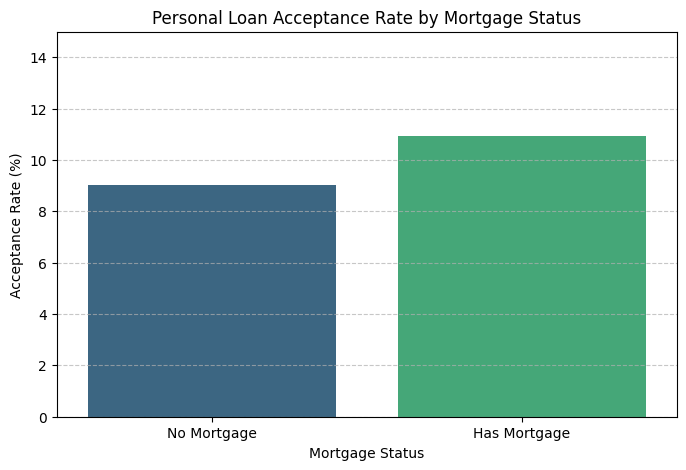

In [27]:
mortgage_loan_acceptance = pd.DataFrame({
    'Mortgage_Status': ['No Mortgage', 'Has Mortgage'],
    'Personal_Loan_Acceptance_Rate (%)': [
        data[data['Mortgage'] == 0]['Personal_Loan'].mean() * 100,
        data[data['Mortgage'] > 0]['Personal_Loan'].mean() * 100
    ]
})

print("Personal Loan Acceptance Rate by Mortgage Status:")
print(mortgage_loan_acceptance)

plt.figure(figsize=(8, 5))
sns.barplot(x='Mortgage_Status', y='Personal_Loan_Acceptance_Rate (%)', data=mortgage_loan_acceptance, palette='viridis')
plt.title('Personal Loan Acceptance Rate by Mortgage Status')
plt.xlabel('Mortgage Status')
plt.ylabel('Acceptance Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 15) # Set a consistent y-axis limit for better comparison
plt.show()

The acceptance rate of Personal Loans for people with a Mortgage is 21.2% higher, than for peopel without a mortgage! This is an important insight.

**Detailed Look at Family Size and Loan Acceptance:** While the pairplot suggested interesting interactions between Family size, Income, and CCAvg, a dedicated analysis of Personal_Loan acceptance rates across different Family sizes would provide a clearer, isolated view. We could see if certain family sizes have significantly higher or lower acceptance rates.


Personal Loan Acceptance Rate by Family Size:
   Family  Personal_Loan  Personal_Loan_Acceptance_Rate (%)
0       1       0.072690                           7.269022
1       2       0.081790                           8.179012
2       3       0.131683                          13.168317
3       4       0.109656                          10.965630


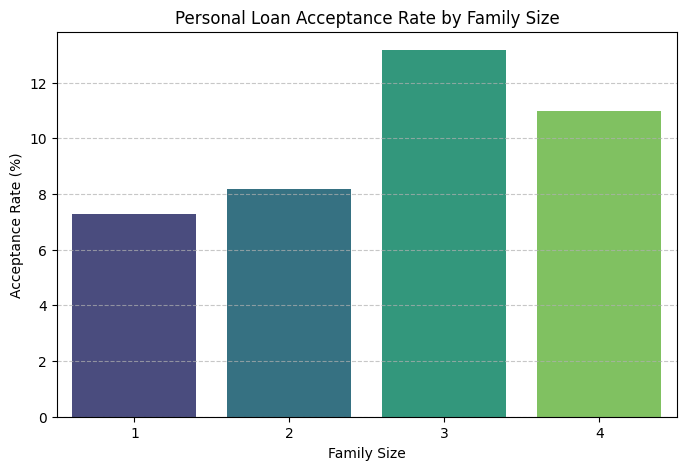

In [28]:
family_loan_acceptance = data.groupby('Family')['Personal_Loan'].mean().reset_index()
family_loan_acceptance['Personal_Loan_Acceptance_Rate (%)'] = family_loan_acceptance['Personal_Loan'] * 100

print("Personal Loan Acceptance Rate by Family Size:")
print(family_loan_acceptance)

# Visualize the acceptance rate
plt.figure(figsize=(8, 5))
sns.barplot(x='Family', y='Personal_Loan_Acceptance_Rate (%)', data=family_loan_acceptance, palette='viridis')
plt.title('Personal Loan Acceptance Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Acceptance Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Families with 3 and 4 have significantly higher acceptance rates.

Distribution of Customers by Family Size:
Family
1    1472
2    1296
3    1010
4    1222
Name: count, dtype: int64


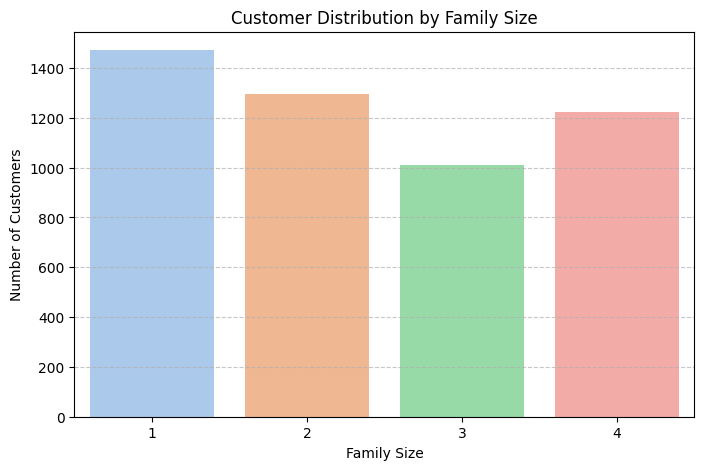

In [29]:
family_size_distribution = data['Family'].value_counts().sort_index()

print("Distribution of Customers by Family Size:")
print(family_size_distribution)

# Visualize the distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Family', data=data, palette='pastel')
plt.title('Customer Distribution by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

2232 (44.64%) users are in families with 3 or more members.

**Binary Features and Loan Acceptance:** We have several binary features like:
- Securities_Account
- CD_Account
- Online
- and CreditCard.

For each of these, we can calculate and visualize the Personal_Loan acceptance rate for both 0 (no) and 1 (yes). This will quantify how having (or not having) these specific banking products or services impacts the likelihood of accepting a personal loan.


Personal Loan Acceptance Rate by Securities_Account:
   Securities_Account  Personal_Loan  Personal_Loan_Acceptance_Rate (%)
0                   0       0.093792                           9.379187
1                   1       0.114943                          11.494253


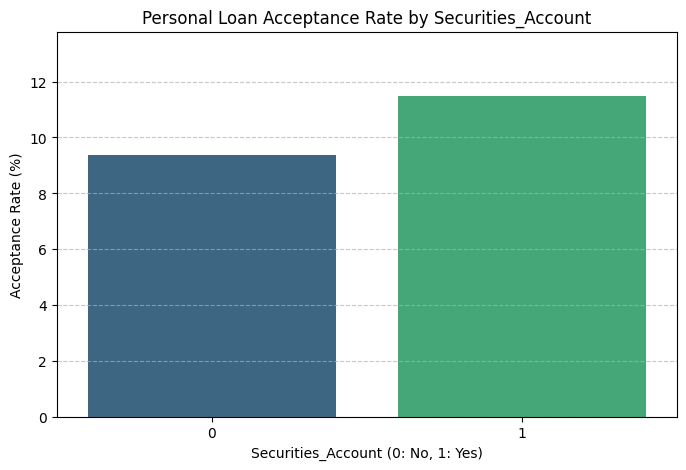


Personal Loan Acceptance Rate by CD_Account:
   CD_Account  Personal_Loan  Personal_Loan_Acceptance_Rate (%)
0           0       0.072371                           7.237122
1           1       0.463576                          46.357616


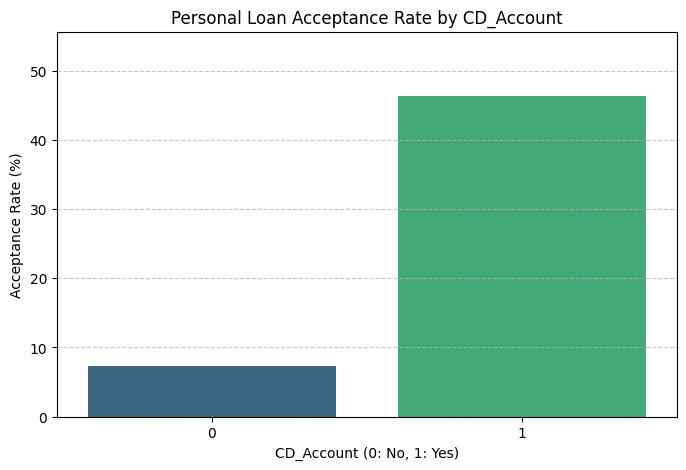


Personal Loan Acceptance Rate by Online:
   Online  Personal_Loan  Personal_Loan_Acceptance_Rate (%)
0       0        0.09375                           9.375000
1       1        0.09752                           9.752011


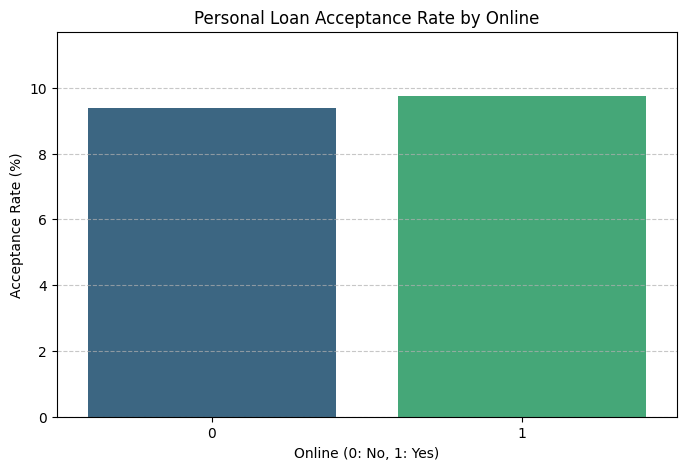


Personal Loan Acceptance Rate by CreditCard:
   CreditCard  Personal_Loan  Personal_Loan_Acceptance_Rate (%)
0           0       0.095467                           9.546742
1           1       0.097279                           9.727891


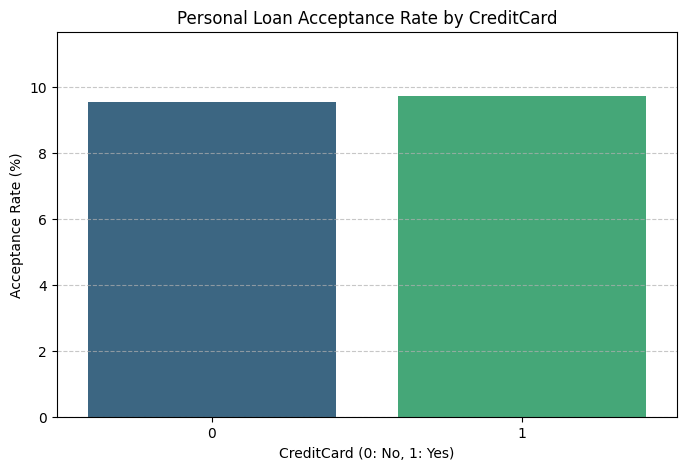

In [30]:
binary_features_to_analyze = ['Securities_Account', 'CD_Account', 'Online', 'CreditCard']

for feature in binary_features_to_analyze:
    # Calculate acceptance rate for the current binary feature
    acceptance_rate = data.groupby(feature)['Personal_Loan'].mean().reset_index()
    acceptance_rate['Personal_Loan_Acceptance_Rate (%)'] = acceptance_rate['Personal_Loan'] * 100

    print(f"\nPersonal Loan Acceptance Rate by {feature}:")
    print(acceptance_rate)

    # Visualize the acceptance rate
    plt.figure(figsize=(8, 5))
    sns.barplot(x=feature, y='Personal_Loan_Acceptance_Rate (%)', data=acceptance_rate, palette='viridis')
    plt.title(f'Personal Loan Acceptance Rate by {feature}')
    plt.xlabel(f'{feature} (0: No, 1: Yes)')
    plt.ylabel('Acceptance Rate (%)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(0, acceptance_rate['Personal_Loan_Acceptance_Rate (%)'].max() * 1.2) # Adjust y-lim dynamically
    plt.show()

We do get an extremely important insight from this. Having a CD_Account increases the likelihood of accepting personal loans from 7.2% to 46.4%. **That is 6.5x higher! And 5x higher than average in the last campaign.**

## EDA Conclusions

Based on the Exploratory Data Analysis, here are the key conclusions regarding factors influencing personal loan adoption.

**Strongest Predictors of Personal Loan Acceptance**:


1. **CD Account Ownership:** This is by far the strongest indicator. Customers with a CD Account are significantly more likely to accept a personal loan (acceptance rate of 46.4%) compared to those without (7.2%). This represents a ~6.5x increase in likelihood and is 5x higher than the overall campaign average.

2. **Income:** A strong positive correlation (0.50) exists between Income and Personal Loan acceptance. Customers with high incomes, particularly those above 100K, show a much higher propensity to accept loans. Conversely, low income strongly correlates with *no* personal loan acceptance.

3. **Credit Card Average Spending (CCAvg):** This feature also shows a notable positive correlation (0.37) with Personal Loan acceptance. Higher CCAvg values, especially above $4K, are associated with increased loan acceptance.


**Combinatorial and Demographic Factors:**

- **Family Size:** Families with 3 or 4 members exhibit significantly higher personal loan acceptance rates (~13.2% and ~11.0% respectively) compared to smaller families (1 or 2 members, ~7.3% and ~8.2% respectively). This suggests that larger family units might have greater financial needs or different spending patterns.
- **Education Level:** There's a positive trend, though weaker (correlation 0.14), where higher education levels (Graduate and Advanced/Professional) correlate with higher personal loan acceptance rates (13.0% and ~13.7%) compared to Undergrads (4.4%).
- **Mortgage Status:** Customers who currently hold a mortgage show a slightly higher personal loan acceptance rate (10.9%) than those without a mortgage (9.0%). This suggests a segment of customers with existing financial commitments are still open to personal loans.



**Less Influential Factors:**
- **Age and Online Banking:** Both Age and Online banking usage showed very weak direct correlations and minimal variation in personal loan acceptance rates across their respective categories or groups. While Age and Experience are highly multicollinear, neither appears to be a primary driver for personal loan acceptance.
- **Securities Account & Other Bank Credit Card:** Having a Securities Account or a Credit Card from another bank showed only a marginal positive association with personal loan acceptance, not as pronounced as CD Account ownership.



**Data Cleaning & Preprocessing Insight:**
- **Experience Anomaly:** The presence of negative 'Experience' values was identified. Although these users showed a 0% personal loan acceptance rate in the sample, the decision to impute these to 0 (assuming new to the workforce) is crucial for model stability and interpretability.



**Overall Takeaway for Model Building:**
The most promising features for your predictive model are CD_Account, Income, CCAvg, and Family. Education and Mortgage status also provide valuable, albeit weaker, signals. The model should heavily leverage these stronger indicators to identify segments of existing liability customers most likely to accept personal loans, thereby enabling targeted and efficient marketing interventions.

## Data Preprocessing

### Experience Anomaly

We will remove the negative experiences in the data, and make it a null value, or 0 years experience.

In [31]:
# Impute negative 'Experience' values to 0
data.loc[data['Experience'] < 0, 'Experience'] = 0

print("Negative 'Experience' values have been imputed to 0.")
print(f"New minimum experience: {data['Experience'].min()}")


Negative 'Experience' values have been imputed to 0.
New minimum experience: 0


### Data Scaling

To make sure we can do proper K-means clustering, we need to make sure all our data points are on the same scale.

We will use `StandardScaler` (Z-score normalization), which transforms the data such that each feature has a mean of 0 and a standard deviation of 1. This ensures that all features contribute equally to the distance computations during clustering.

Before scaling, we will drop `ID` and `ZIPCode` as they are identifiers and not meaningful features for clustering.

In [32]:
data_for_clustering = data.drop(columns=['ID', 'ZIPCode', 'Personal_Loan', 'Age_Group'])

# Separate features for scaling: numerical features (excluding binary/categorical already handled)
numerical_cols = ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage']

# Initialize the StandardScaler
scaler = StandardScaler()

# Scale the numerical features
data_for_clustering[numerical_cols] = scaler.fit_transform(data_for_clustering[numerical_cols])

print("Scaled data head:")
display(data_for_clustering.head())

print("\nScaled data description:")
display(data_for_clustering.describe().T)

Scaled data head:


,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Securities_Account,CD_Account,Online,CreditCard
0,-1.774417,-1.671390,-0.538229,1.397414,-0.193385,-1.049078,-0.555524,1,0,0,0
1,-0.029524,-0.097873,-0.864109,0.525991,-0.250611,-1.049078,-0.555524,1,0,0,0
2,-0.552992,-0.447543,-1.363793,-1.216855,-0.536736,-1.049078,-0.555524,0,0,0,0
3,-0.901970,-0.972049,0.569765,-1.216855,0.436091,0.141703,-0.555524,0,0,0,0
4,-0.901970,-1.059467,-0.625130,1.397414,-0.536736,0.141703,-0.555524,0,0,0,1



Scaled data description:


,count,mean,std,min,25%,50%,75%,max
Age,5000.0,-2.131628e-18,1.000100,-1.948906,-0.901970,-0.029524,0.842923,1.889859
Experience,5000.0,1.428191e-16,1.000100,-1.758808,-0.884631,-0.010455,0.863721,2.000150
Income,5000.0,1.449507e-16,1.000100,-1.428969,-0.755483,-0.212348,0.526315,3.263712
Family,5000.0,1.001865e-16,1.000100,-1.216855,-1.216855,-0.345432,0.525991,1.397414
CCAvg,5000.0,-6.394885e-17,1.000100,-1.108987,-0.708412,-0.250611,0.321641,4.613525
Education,5000.0,2.557954e-17,1.000100,-1.049078,-1.049078,0.141703,1.332484,1.332484
Mortgage,5000.0,-5.613288e-17,1.000100,-0.555524,-0.555524,-0.555524,0.437558,5.688108
Securities_Account,5000.0,1.044000e-01,0.305809,0.000000,0.000000,0.000000,0.000000,1.000000
CD_Account,5000.0,6.040000e-02,0.238250,0.000000,0.000000,0.000000,0.000000,1.000000
Online,5000.0,5.968000e-01,0.490589,0.000000,0.000000,1.000000,1.000000,1.000000


## Model Building

Looking at our objective, K-means clustering seems to achieve our goal best:


> the goal is to enable targeted segmentation and more precise marketing interventions that improve campaign conversion rates, optimize marketing spend, and enhance overall profitability through higher-quality loan portfolio growth.


**K-means clustering** is ideal for segmenting your customer base into distinct groups (clusters) that share similar demographic and behavioral traits. These segments can then be targeted with customized marketing strategies.

**Decision Tree** is a good approach to segmenting users as well, based on specific targets, such as setting potential conversion rates by segments. And Decision Trees are less Sensitive to "unscaled" data.

### Model Evaluation Criterion

#### Elbow Method to determine Optimal K

Using the Elbow Method to find the correct number of Clusters.

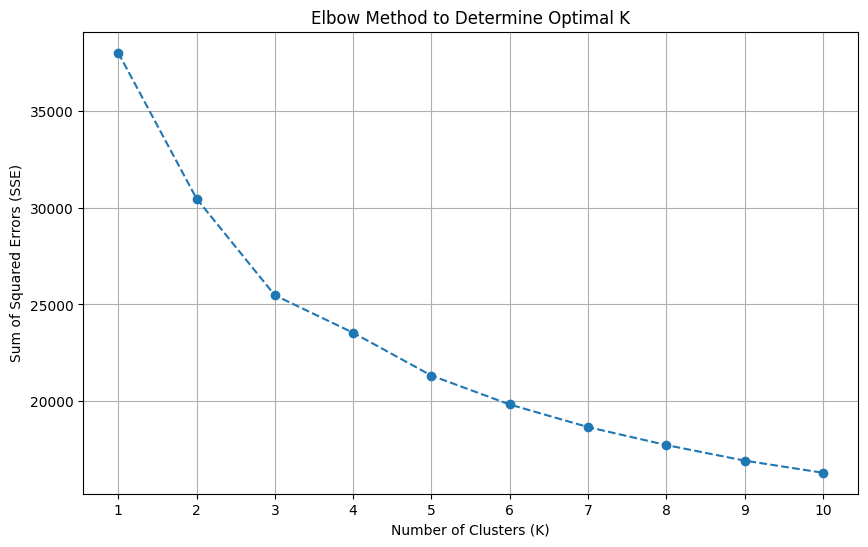

In [33]:
sse = [] # Sum of Squared Errors
k_values = range(1, 11) # Test k from 1 to 10

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RS, n_init=10) # n_init to suppress warning
    kmeans.fit(data_for_clustering)
    sse.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(k_values, sse, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.xticks(k_values)
plt.grid(True)
plt.show()


From the graph, the most pronounced 'elbow' appears to be around **K=3** or **K=4**. After this point, the decrease in SSE becomes more gradual.

- **K=3** shows a significant drop from K=2.
- **K=4** also shows a good drop from K=3, but the improvement lessens afterwards.

To validate the optimal number of clusters suggested by the Elbow Method, I will calculate and visualize the Silhouette Score for a range of K values, which helps in identifying the density and separation of the clusters.



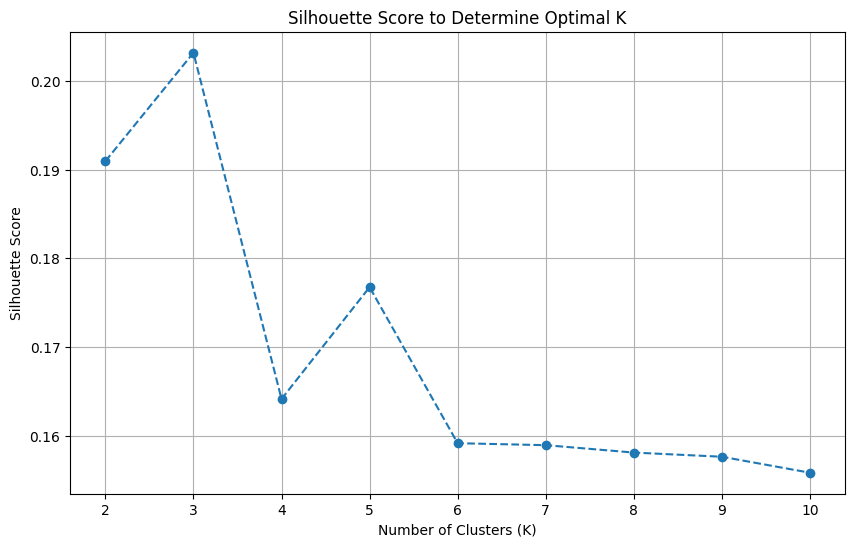

In [34]:
silhouette_scores = [] # List to store silhouette scores
k_values_silhouette = range(2, 11) # Test k from 2 to 10 (silhouette score is not defined for k=1)

for k in k_values_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=RS, n_init=10) # n_init to suppress warning
    kmeans.fit(data_for_clustering)
    score = silhouette_score(data_for_clustering, kmeans.labels_)
    silhouette_scores.append(score)

# Plot the Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(k_values_silhouette, silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score to Determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values_silhouette)
plt.grid(True)
plt.show()

According to the Silhuette Analysis **K=3** is a better number of clusters.


### Model Building

### Performing K-means Clustering

Based on the Silhouette Score analysis, we will now perform K-means clustering with **K=3**.

In [35]:
kmeans = KMeans(n_clusters=3, random_state=RS, n_init=10) # Using 3 clusters as determined by Silhouette Score
kmeans.fit(data_for_clustering)

# Add the cluster labels to the data_for_clustering DataFrame
data_for_clustering['Cluster'] = kmeans.labels_

# Printing the data to check if the cluster was added correctly
print("DataFrame with cluster assignments (first 5 rows):")
display(data_for_clustering.head())

DataFrame with cluster assignments (first 5 rows):


,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Securities_Account,CD_Account,Online,CreditCard,Cluster
0,-1.774417,-1.671390,-0.538229,1.397414,-0.193385,-1.049078,-0.555524,1,0,0,0,2
1,-0.029524,-0.097873,-0.864109,0.525991,-0.250611,-1.049078,-0.555524,1,0,0,0,2
2,-0.552992,-0.447543,-1.363793,-1.216855,-0.536736,-1.049078,-0.555524,0,0,0,0,2
3,-0.901970,-0.972049,0.569765,-1.216855,0.436091,0.141703,-0.555524,0,0,0,0,2
4,-0.901970,-1.059467,-0.625130,1.397414,-0.536736,0.141703,-0.555524,0,0,0,1,2


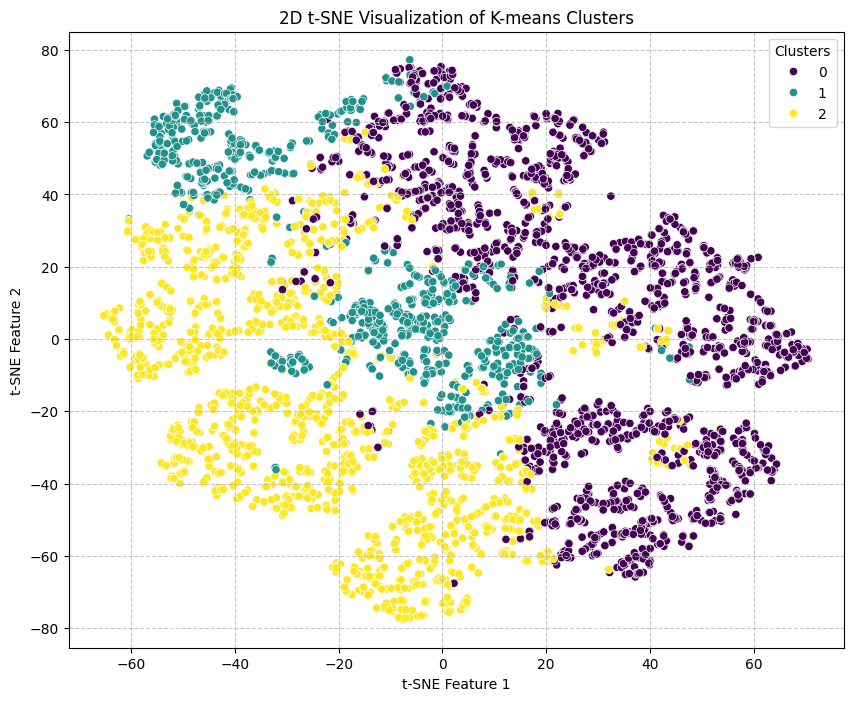

In [36]:
# Perform t-SNE for 2D visualization
tsne_2d = TSNE(n_components=2, random_state=RS)
tsne_2d_data = tsne_2d.fit_transform(data_for_clustering.drop(columns=['Cluster']))

# Create a DataFrame for 2D t-SNE results
tsne_2d_df = pd.DataFrame(data=tsne_2d_data, columns=['Feature 1', 'Feature 2'])
tsne_2d_df['Clusters'] = data_for_clustering['Cluster']

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Feature 1', y='Feature 2', hue='Clusters', palette='viridis', data=tsne_2d_df, legend='full')
plt.title('2D t-SNE Visualization of K-means Clusters')
plt.xlabel('t-SNE Feature 1')
plt.ylabel('t-SNE Feature 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [37]:
# Perform t-SNE for 3D visualization
tsne_3d = TSNE(n_components=3, random_state=RS)
tsne_3d_data = tsne_3d.fit_transform(data_for_clustering.drop(columns=['Cluster']))

# Create a DataFrame for 3D t-SNE results
tsne_3d_df = pd.DataFrame(data=tsne_3d_data, columns=['Feature 1', 'Feature 2', 'Feature 3'])
tsne_3d_df['Clusters'] = data_for_clustering['Cluster']

# Create 3D scatter plot using Plotly Express
fig = px.scatter_3d(tsne_3d_df, x='Feature 1', y='Feature 2', z='Feature 3', color='Clusters', title='3D t-SNE Visualization of K-means Clusters')
fig.show()

### Profile K-Means Clusters

Now that we have assigned customers to clusters, the next important step is to understand the characteristics of each cluster. This involves analyzing the mean (or median) values of the original features within each cluster to see how they differ from each other and from the overall dataset.

In [38]:
# Combine original unscaled data with cluster labels
data_clustered = data.copy()
data_clustered['Cluster'] = data_for_clustering['Cluster'] # Use cluster labels from the scaled data

# Drop non-numeric or irrelevant columns for mean calculation (e.g., 'Age_Group')
data_clustered = data_clustered.drop(columns=['Age_Group', 'ID', 'ZIPCode'])

# Calculate the mean of each feature for each cluster, only for numeric columns
cluster_profiles = data_clustered.groupby('Cluster').mean(numeric_only=True)

# Display the cluster profiles
print("Cluster Profiles (Mean of Original Features):")
display(cluster_profiles)

# Optionally, you can also compare with the overall mean of the dataset
print("\nOverall Mean of Original Features:")
display(data.mean(numeric_only=True).to_frame().T)

Cluster Profiles (Mean of Original Features):


,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
Cluster,,,,,,,,,,,,
0,55.514527,30.210403,57.624649,2.395970,1.343425,1.964855,43.667291,0.039363,0.100750,0.041706,0.605904,0.300843
1,43.939535,18.938372,145.675581,1.911628,4.713012,1.508140,116.213953,0.368605,0.111628,0.155814,0.609302,0.293023
2,35.112662,9.891326,60.129113,2.604686,1.380673,1.951645,44.548355,0.039382,0.105184,0.039382,0.581755,0.287139



Overall Mean of Original Features:


,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,2500.5,45.3384,20.1196,73.7742,93169.257,2.3964,1.937938,1.881,56.4988,0.096,0.1044,0.0604,0.5968,0.294


### Cluster Profiles Conclusions

**Cluster 0 (Older, Mid-Income, Lower Loan Acceptance):**

- Age/Experience: Oldest group (mean age 55.5, highest experience 30.2).
- Income: Mid-range income (57.6k), below the overall average.
- Personal Loan: Very low acceptance rate (3.9%), significantly below the overall average (9.6%).
- Mortgage: Moderate mortgage value (43.7k).
- CCAvg: Lowest credit card spending (1.34k).
- Education: Higher education level (1.96, closer to Graduate/Advanced).
- CD Account: Low CD account ownership (4.2%), similar to Cluster 2.
- **Summary:** This segment represents mature customers, likely stable, but with lower income and spending, and very little interest in personal loans.


**Cluster 1 (High-Value, High Loan Acceptance):**

- Age/Experience: Middle-aged group (mean age 43.9, experience 18.9).
- Income: Highest income (145.7k), significantly above average.
- Personal Loan: Highest acceptance rate by far (36.9%), nearly 4x the overall average. This is your target segment!
- Mortgage: Highest mortgage value (116.2k).
- CCAvg: Highest credit card spending (4.71k), well above average.
- Education: Lowest education level (1.51, closer to Undergrad/Graduate), which is an interesting contrast to the higher income, and this could be investigated further
- CD Account: Highest CD account ownership (15.6%), indicating financial savviness.
- **Summary:** This is your most valuable segment – high earners, high spenders, and most importantly, highly receptive to personal loan offers. They are financially active and seem to trust the bank with various products.


**Cluster 2 (Younger, Mid-Income, Lower Loan Acceptance):**

- Age/Experience: Youngest group (mean age 35.1, lowest experience 9.9).
- Income: Mid-range income (60.1k), below the overall average, similar to Cluster 0.
- Personal Loan: Very low acceptance rate (3.9%), similar to Cluster 0 and significantly below the overall average.
- Mortgage: Moderate mortgage value (44.5k), similar to Cluster 0.
- CCAvg: Low credit card spending (1.38k), similar to Cluster 0.
- Education: Higher education level (1.95, closer to Graduate/Advanced), similar to Cluster 0.
- Family: Highest family size (2.6, suggesting a slightly larger family structure).
- CD Account: Low CD account ownership (3.9%), similar to Cluster 0.
- **Summary:** This segment consists of younger customers, also with moderate income and spending. They are least interested in personal loans, perhaps due to being earlier in their career or different financial priorities.


## Decision Tree Model

First, let's prepare the data for the Decision Tree model. We will define our features (X) and target variable (y). Since Decision Trees do not require feature scaling, we will use the original `data` DataFrame, but we need to drop non-predictive columns like `ID`, `ZIPCode`, and the `Age_Group` which was created for EDA.

We also need to ensure that the `Experience` anomaly has been handled (which it has been in the preprocessing step).

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Prepare the data for Decision Tree
# Drop non-predictive features and the target variable for X
X = data.drop(columns=['ID', 'ZIPCode', 'Personal_Loan', 'Age_Group'])
y = data['Personal_Loan']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3500, 11)
X_test shape: (1500, 11)
y_train shape: (3500,)
y_test shape: (1500,)


Now, let's train a Decision Tree Classifier and make predictions.

In [40]:
# Initialize and train the Decision Tree Classifier
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dtree.predict(X_test)

print("Decision Tree Classifier trained and predictions made.")

Decision Tree Classifier trained and predictions made.


In [41]:
# Evaluate the model with the updated random_state
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9806666666666667

Confusion Matrix:
 [[1340   16]
 [  13  131]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1356
           1       0.89      0.91      0.90       144

    accuracy                           0.98      1500
   macro avg       0.94      0.95      0.94      1500
weighted avg       0.98      0.98      0.98      1500




- 1340 true negatives (correctly predicted no loan)
- 131 true positives (correctly predicted loan acceptance)
- 16 false positives (predicted loan, wasn't)
- 13 false negatives (missed actual loan acceptors)

Accuracy: ~98%. Only 29 misclassifications out of 1500.

The classes are heavily imbalanced (~1356 vs ~144). With 90% being "no loan," even a dumb model predicting "no" every time gets 90% accuracy.

Feature Importances for Decision Tree (updated):


,importance
Income,0.416735
Education,0.301375
Family,0.147533
CCAvg,0.061447
Age,0.022322
Experience,0.015996
Mortgage,0.015685
CD_Account,0.012747
Online,0.003964
Securities_Account,0.002195


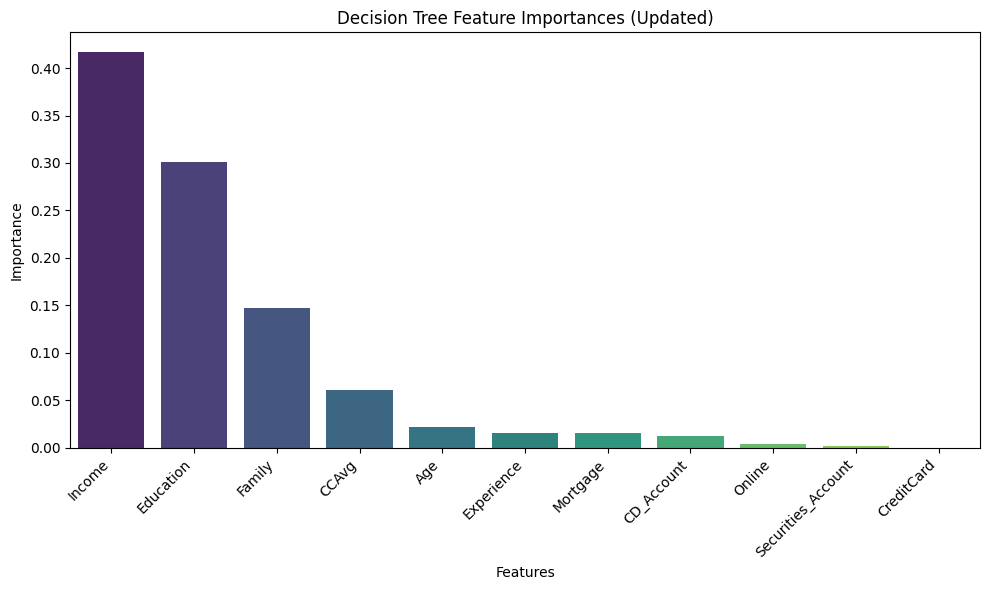

In [42]:
# Get feature importances for the updated model
feature_importances = pd.DataFrame(dtree.feature_importances_, index=X_train.columns, columns=['importance']).sort_values('importance', ascending=False)

print("Feature Importances for Decision Tree (updated):")
display(feature_importances)

# Visualize feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.index, y=feature_importances['importance'], palette='viridis')
plt.title('Decision Tree Feature Importances (Updated)')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

To understand which features are most important for the Decision Tree's decisions, we can inspect its `feature_importances_` attribute.

- Income the most critical factor, reinforcing our EDA findings. High income is a strong predictor.
- Education is surprisingly the second most influential feature for the Decision Tree.
- Family: Family size plays a substantial role, particularly larger families as observed in EDA.
- CCAvg: Average credit card spending also contributes to the model's predictive power.
- Age: While not as strong as others, it still contributes more than Experience and Mortgage.
- CD_Account, which was a very strong predictor in the univariate analysis (6.5x higher acceptance rate), has a lower direct importance here. This might be because its effect is captured through interactions with other highly important features like Income or Education within the tree structure.
- Securities_Account and CreditCard have negligible importance for this model.



In [43]:
print(f"The Decision Tree has {dtree.tree_.max_depth} layers.")

The Decision Tree has 12 layers.


This tree is too complex, I will visualize and figure out how we can avoid overfitting.

#### Visualizing the Decision Tree

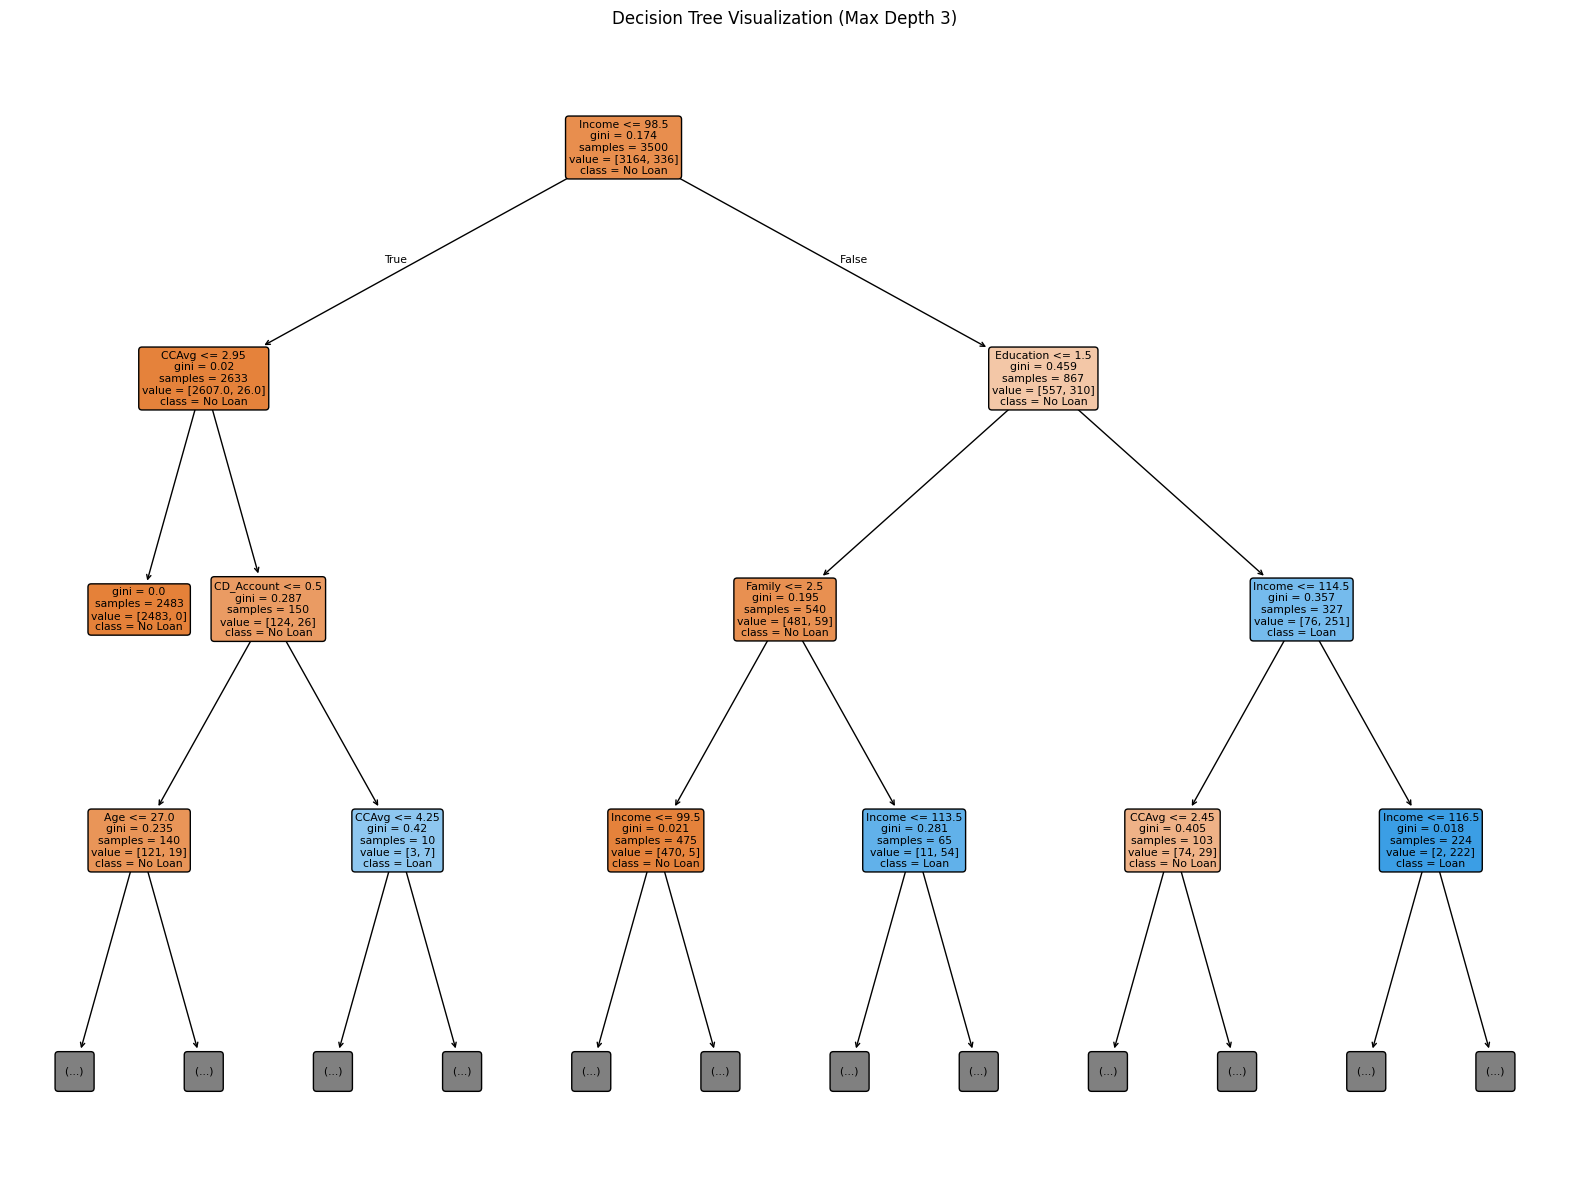

In [44]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 15)) # Adjust figure size for better readability
plot_tree(dtree, filled=True, rounded=True, class_names=['No Loan', 'Loan'], feature_names=X_train.columns, max_depth=3) # Limiting max_depth for visualization clarity
plt.title('Decision Tree Visualization (Max Depth 3)')
plt.show()

#### Checking Leaf Node Sample Counts

In [45]:
leaf_nodes = dtree.tree_.children_left == -1
leaf_samples = dtree.tree_.n_node_samples[leaf_nodes]

min_samples_in_leaf = leaf_samples.min()
max_samples_in_leaf = leaf_samples.max()

print(f"Minimum samples in any leaf node: {min_samples_in_leaf}")
print(f"Maximum samples in any leaf node: {max_samples_in_leaf}")

# Check if any leaf node has less than 10 samples
leaves_less_than_10 = leaf_samples[leaf_samples < 10]

if len(leaves_less_than_10) > 0:
    print(f"\nNumber of leaf nodes with less than 10 samples: {len(leaves_less_than_10)}")
    print(f"Sample counts in these nodes: {leaves_less_than_10}")
    print("This indicates potential overfitting, and pruning or setting `min_samples_leaf` might be beneficial.")
else:
    print("\nAll leaf nodes have 10 or more samples. This suggests the tree is not overfitting to very small groups of data.")

Minimum samples in any leaf node: 1
Maximum samples in any leaf node: 2483

Number of leaf nodes with less than 10 samples: 49
Sample counts in these nodes: [2 4 1 1 6 2 1 7 4 1 2 1 1 6 5 2 1 6 1 3 2 1 3 1 2 1 2 3 9 1 2 6 2 4 1 3 1
 5 2 9 3 3 1 2 3 6 1 2 6]
This indicates potential overfitting, and pruning or setting `min_samples_leaf` might be beneficial.


The analysis confirms that our Decision Tree has a number of leaf nodes with very few samples (49 nodes have less than 10 samples, with some as low as 1). This is a classic sign of overfitting.

I'm adding a min_samples_leaf parameter to our DecisionTreeClassifier. This parameter specifies the minimum number of samples required to be at a leaf node. By setting it to 10, we can prune the tree and encourage it to generalize better.

Decision Tree Classifier re-trained with min_samples_leaf=10.

Accuracy: 0.9906666666666667

Confusion Matrix:
 [[1351    5]
 [   9  135]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1356
           1       0.96      0.94      0.95       144

    accuracy                           0.99      1500
   macro avg       0.98      0.97      0.97      1500
weighted avg       0.99      0.99      0.99      1500


Feature Importances for Decision Tree (after pruning with min_samples_leaf=10):


,importance
Income,0.457955
Education,0.326380
Family,0.144429
CCAvg,0.043344
Experience,0.015026
CD_Account,0.010989
Online,0.001877
Age,0.000000
Mortgage,0.000000
Securities_Account,0.000000


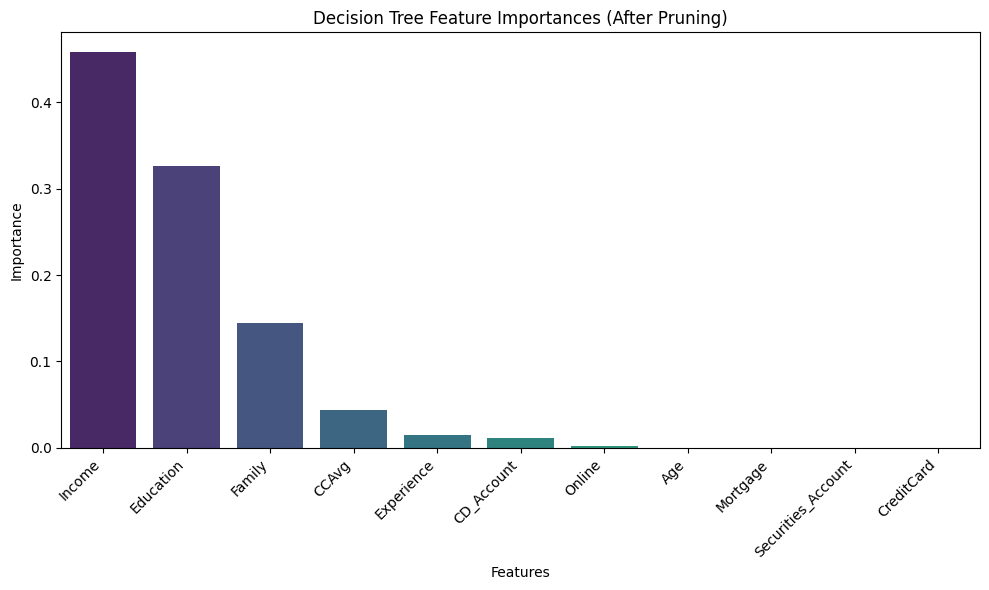


The Decision Tree has 9 layers (after pruning with min_samples_leaf=10).


In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize and train the Decision Tree Classifier with min_samples_leaf=10
dtree = DecisionTreeClassifier(random_state=42, min_samples_leaf=10)
dtree.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dtree.predict(X_test)

print("Decision Tree Classifier re-trained with min_samples_leaf=10.")

# Evaluate the pruned model
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Get feature importances for the pruned model
feature_importances_pruned = pd.DataFrame(dtree.feature_importances_, index=X_train.columns, columns=['importance']).sort_values('importance', ascending=False)

print("\nFeature Importances for Decision Tree (after pruning with min_samples_leaf=10):")
display(feature_importances_pruned)

# Visualize feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_pruned.index, y=feature_importances_pruned['importance'], palette='viridis')
plt.title('Decision Tree Feature Importances (After Pruning)')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print the new tree depth
print(f"\nThe Decision Tree has {dtree.tree_.max_depth} layers (after pruning with min_samples_leaf=10).")

### Decision Tree Conclusions (After Pruning with `min_samples_leaf=10`)

After pruning the Decision Tree with `min_samples_leaf=10`, we observe a notable improvement in model generalization and a more concise structure, addressing the potential overfitting identified earlier.

**Performance Metrics:**
*   **Accuracy:** Improved slightly to ~99.07% (from ~98.07%).
*   **Confusion Matrix:** Reduced False Positives from 16 to 5 and False Negatives from 13 to 9. This means the model is now better at correctly identifying customers who will *not* take a loan (fewer false positives) and still maintains a very low rate of missing potential loan acceptors (false negatives).
*   **Classification Report (for Personal_Loan=1):**
    *   **Precision:** Increased to 0.96 (from 0.89).
    *   **Recall:** Maintained a strong 0.94 (from 0.91).
    *   **F1-score:** Increased to 0.95 (from 0.90).

These improved metrics indicate that the pruned model is more precise in its positive predictions while largely retaining its ability to capture actual loan acceptors. The reduction in False Positives is particularly valuable for optimizing marketing spend, as it means fewer resources are wasted on customers incorrectly predicted to take a loan.

**Tree Complexity:**
*   The tree depth was reduced from 12 layers to **9 layers**, confirming that pruning successfully simplified the model structure without sacrificing predictive power, and in fact, enhancing it.

**Feature Importances (Pruned Model):**
*   **Income (0.458):** Remains the most critical factor, with its importance slightly increasing after pruning, reinforcing its dominant role.
*   **Education (0.326):** Continues to be the second most influential feature, also showing a slight increase in importance.
*   **Family (0.144):** Retains significant importance, further confirming that larger families are a key segment.
*   **CCAvg (0.043):** Still a relevant factor, though its importance is somewhat reduced compared to the unpruned tree.
*   **CD_Account (0.011):** Continues to hold a smaller direct importance within the tree structure, likely due to its strong binary nature being captured earlier in the tree splits or through interactions.
*   **Age, Mortgage, Securities_Account, CreditCard, Online:** Showed very low or zero direct importance in the pruned tree, suggesting their contribution is minimal or fully captured by other features or the pruning process simplified away less impactful splits involving these features.

**Overall Impact:**
The pruned Decision Tree is a more robust and interpretable model. It provides excellent predictive capability for identifying potential personal loan customers, significantly improving upon the initial, potentially overfitted model. The high precision for loan acceptors means marketing efforts can be more efficiently targeted, and the still high recall ensures that very few potential customers are missed. This model is well-suited for deployment, especially when combined with the customer segmentation insights from K-means clustering.

## Model Performance Comparison and Final Model Selection

### Approach to Model Comparison

Our objective is twofold: first, to develop a **predictive classification model** for personal loan adoption, and second, to enable **targeted segmentation** for precise marketing interventions. We have developed two distinct models:

1.  **K-means Clustering (Unsupervised Learning):** This model is excellent for identifying natural groupings (segments) within our customer base based on their features. It's about understanding *who* our customers are and *how they naturally group together*.

2.  **Decision Tree Classifier (Supervised Learning):** This model is built to *predict* whether a customer will accept a personal loan. It focuses on identifying the specific characteristics that lead to loan acceptance or rejection. It's about *what characteristics make a customer likely to accept a loan*.

To compare them effectively, we must recognize their different purposes. K-means provides valuable `segmentation` insights (identifying target groups), while the Decision Tree provides `predictive power` (identifying individual customers likely to convert). Both contribute to the overall objective but in different ways. The ultimate goal is to leverage both to maximize campaign efficiency and profitability.

### Model Comparison

**K-means Clustering Strengths:**

*   **Customer Segmentation:** Successfully identified 3 distinct customer segments with varying characteristics and loan acceptance propensities. Cluster 1, in particular, was identified as a high-value segment with a significantly higher personal loan acceptance rate (36.9%).
*   **Actionable for Marketing Strategy:** The detailed profiles of each cluster offer concrete insights for tailoring marketing messages and product offerings to specific groups.
*   **Unsupervised Insights:** Provided a data-driven way to understand the underlying structure of the customer base without relying on historical loan acceptance labels.

**Decision Tree Classifier Strengths:**

*   **High Predictive Accuracy:** The pruned Decision Tree achieved an excellent accuracy of ~99.07%, with high precision (0.96) and recall (0.94) for the target class (Personal_Loan=1).
*   **Identifies Key Drivers:** Clearly pinpointed `Income`, `Education`, and `Family` size as the most influential features for predicting loan acceptance.
*   **Interpretability:** As a white-box model, the decision-making logic is transparent, allowing for easy explanation of why a particular customer is predicted to accept or reject a loan.
*   **Direct Targeting:** Provides a mechanism to directly identify individual customers most likely to accept a loan, optimizing direct marketing efforts and reducing wasteful spending.
*   **Reduced Overfitting:** Pruning with `min_samples_leaf=10` successfully reduced model complexity and improved generalization.

---

### Final Model Selection

Given our primary objective of developing a **predictive classification model** to identify customers likely to accept personal loans, the **Decision Tree Classifier** is the chosen primary model for direct prediction and targeting. Its high performance metrics and clear identification of key features make it highly suitable for this task.

However, the insights gained from **K-means Clustering** are invaluable as a complementary tool. The cluster profiles provide a deeper understanding of the segments, which can be used to refine marketing strategies. For instance, customers predicted to accept a loan by the Decision Tree could be further segmented by their K-means cluster to tailor the messaging even more effectively.

**Therefore, the recommended strategy is a hybrid approach:**

1.  **Use the Decision Tree Classifier** to predict which individual customers are most likely to accept a personal loan.
2.  **Augment these predictions with K-means Cluster insights** to customize marketing campaigns. For example, a customer predicted as 'loan acceptor' who falls into 'Cluster 1' (High-Value, High Loan Acceptance) might receive a premium offer, while a 'loan acceptor' from another cluster might receive a different type of communication.

*Note that our Data is also limited, and 10x the data will likely yield different results for both models*

## Actionable Insights and Business Recommendations

Based on the comprehensive analysis using both K-means clustering and the Decision Tree Classifier, here are actionable recommendations for AllLife Bank to optimize its personal loan campaigns:

1.  **Prioritize High-Income, Educated, and Larger Families:** The Decision Tree clearly shows that `Income`, `Education`, and `Family` size are the top three predictors of personal loan acceptance. Marketing efforts should heavily focus on customers exhibiting these characteristics.
    *   **Income:** Target customers with higher incomes, particularly those above $100K. The model indicates low income almost always leads to non-acceptance.
    *   **Education:** Focus on Graduate and Advanced/Professional degree holders, who show significantly higher acceptance rates.
    *   **Family:** Emphasize customers with family sizes of 3 or 4, as they have a higher propensity for loan acceptance.

2.  **Leverage CD Account Ownership:** Customers with `CD_Account`s are extremely receptive to personal loans (46.4% acceptance rate). This segment should be aggressively targeted, perhaps with exclusive offers or pre-approved loans, as they represent a highly engaged and profitable group.

3.  **Target K-means Cluster 1 (High-Value Segment):** This cluster is characterized by high income, high credit card spending, high mortgage values, and the highest personal loan acceptance rate (36.9%). This is the **primary target segment** for maximizing conversion. Marketing campaigns should be tailor-made to appeal to their sophisticated financial needs and high-value status. Examples include premium loan products, wealth management advice, or personalized financial planning services alongside loan offers.

4.  **Avoid Low-Propensity Segments (K-means Clusters 0 and 2):** Clusters 0 and 2 show very low personal loan acceptance rates. Redirect marketing spend away from these groups for personal loan campaigns to avoid wasteful expenditures. Instead, explore offering other banking products or services that align with their distinct profiles (e.g., retirement planning for older, lower-income Cluster 0; basic banking services or introductory products for younger, lower-income Cluster 2).

5.  **Data Quality Monitoring:** Continue to monitor and address data quality issues, such as negative 'Experience' values, to ensure model stability and accuracy. Imputing negative `Experience` to 0 was a crucial step.

6.  **Future Enhancements:** Explore more advanced Decision Tree hyperparameter tuning (e.g., `max_depth`, `ccp_alpha`), or investigate ensemble methods like Random Forests or Gradient Boosting for potentially even higher predictive power. Further analysis of `ZIPCode` could reveal geographical market opportunities.

---

# Appendix

## Comparing Group No_Mortgage vs Group Has_Mortgage

## Failed Pairplot Analysis

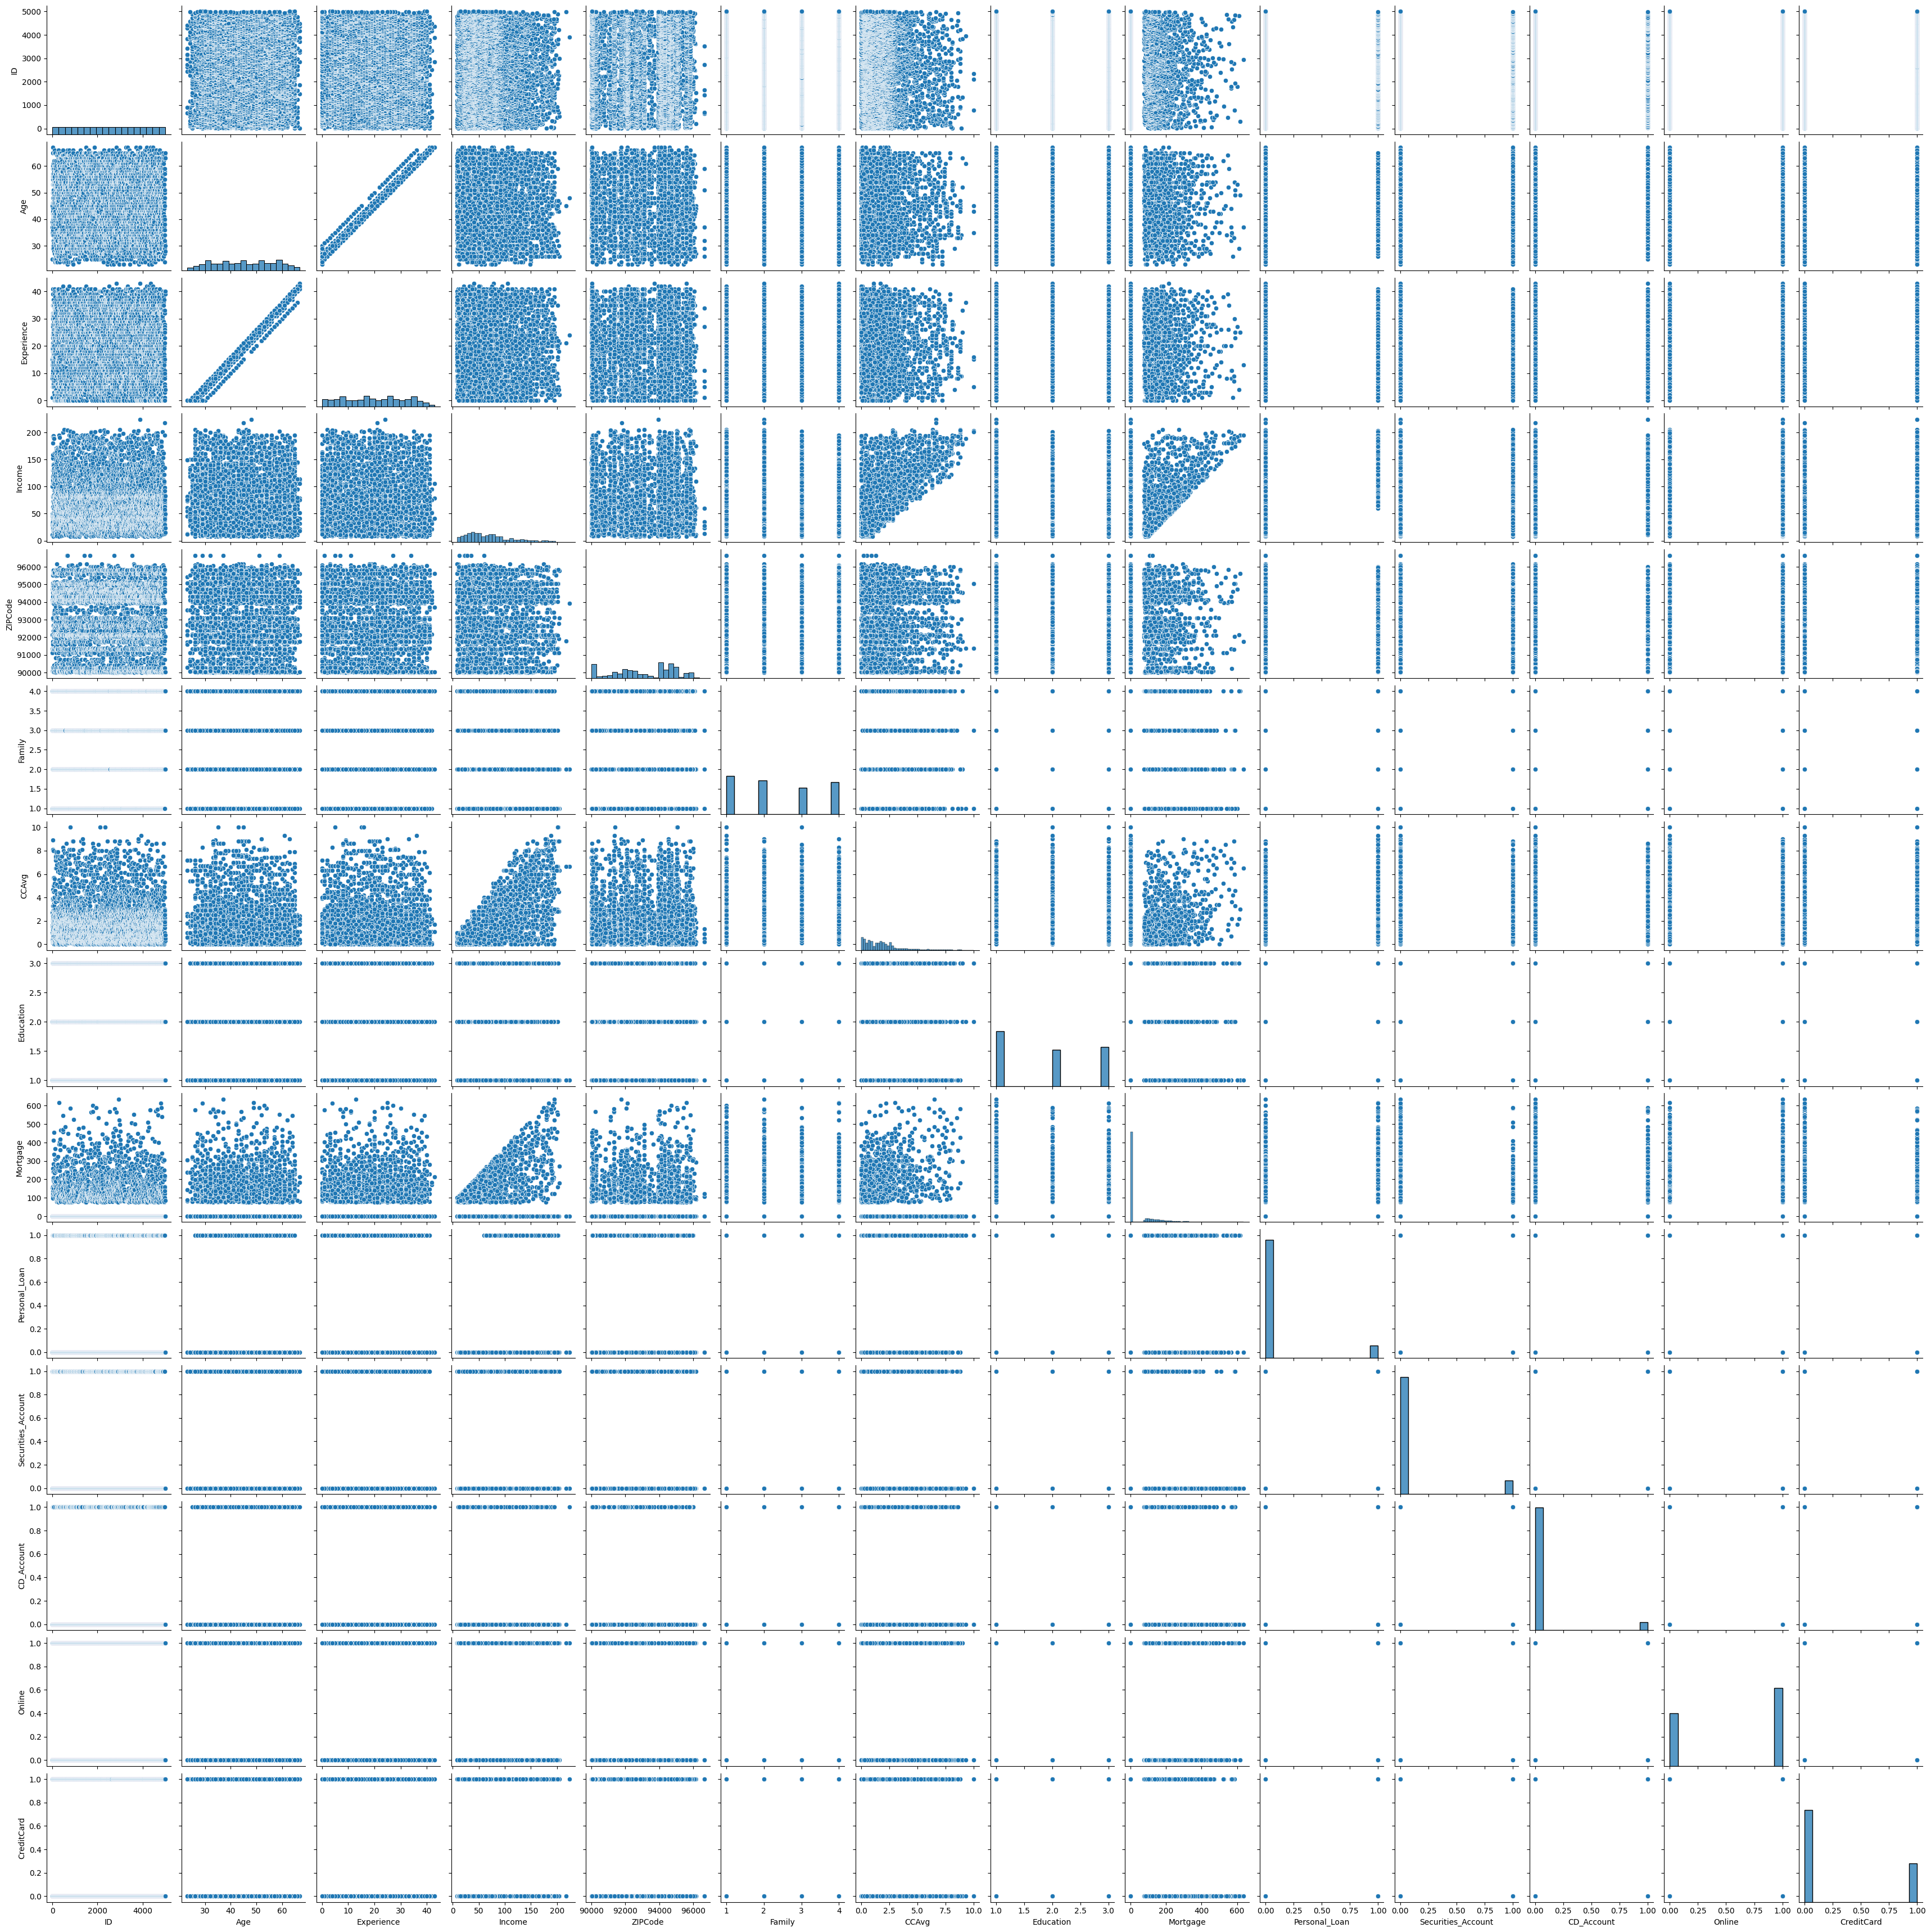

In [47]:
# plotting a pairplot
sns.pairplot(data);

I failed getting any meaningful out of the Pairplot analysis, so the analysis I kept in the Case Study was dont using a KDE apporach.

## Zipcode Profiling

I am considering to do an analysis of the Zipcodes and the behaviour.

Number of unique ZIP Codes: 467

Top 10 most frequent ZIP Codes:
ZIPCode
94720    169
94305    127
95616    116
90095     71
93106     57
93943     54
92037     54
91320     53
91711     52
94025     52
Name: count, dtype: int64

Personal Loan Acceptance Rate for Top 10 Most Frequent ZIP Codes:


,ZIPCode,Personal_Loan,Personal_Loan_Acceptance_Rate (%)
0,90095,0.112676,11.267606
8,94720,0.112426,11.242604
7,94305,0.102362,10.236220
3,92037,0.092593,9.259259
6,94025,0.076923,7.692308
2,91711,0.076923,7.692308
5,93943,0.074074,7.407407
4,93106,0.070175,7.017544
9,95616,0.051724,5.172414
1,91320,0.037736,3.773585


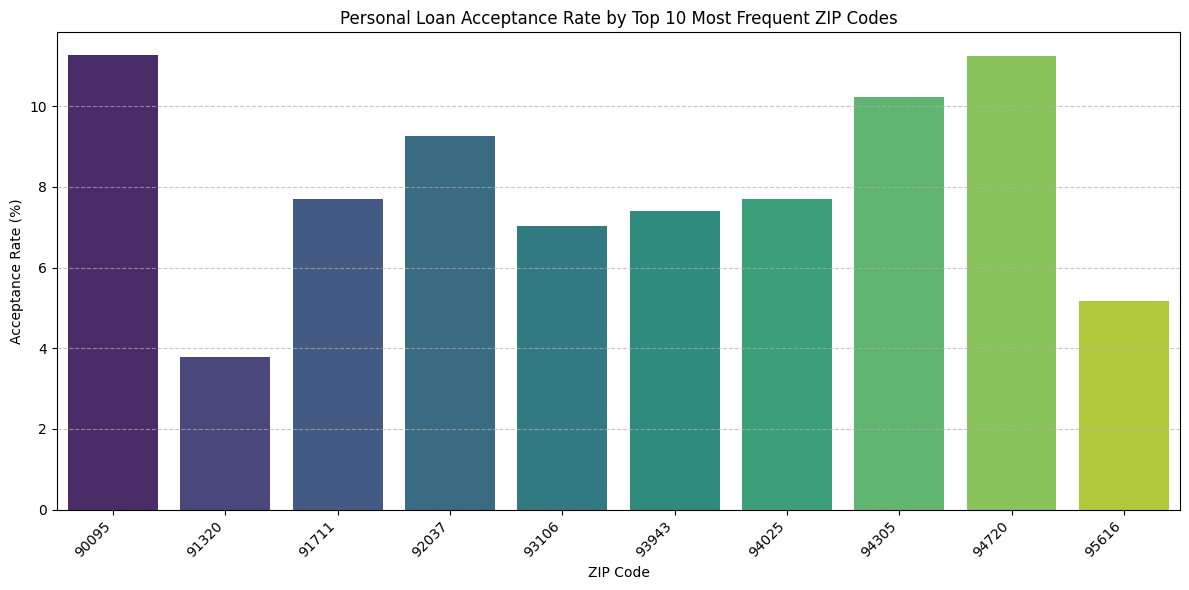

In [48]:
# Explore ZIPCode as a categorical feature

# Number of unique ZIP Codes
num_unique_zipcodes = data['ZIPCode'].nunique()
print(f"Number of unique ZIP Codes: {num_unique_zipcodes}")

# Display the top 10 most frequent ZIP Codes
print("\nTop 10 most frequent ZIP Codes:")
print(data['ZIPCode'].value_counts().head(10))

# Analyze personal loan acceptance rate for the top 10 most frequent ZIP Codes
# First, get the top 10 ZIP Codes
top_10_zipcodes = data['ZIPCode'].value_counts().head(10).index

# Filter the data for these top ZIP Codes
data_top_zipcodes = data[data['ZIPCode'].isin(top_10_zipcodes)]

# Calculate loan acceptance rate for each of these ZIP Codes
zipcode_loan_acceptance = data_top_zipcodes.groupby('ZIPCode')['Personal_Loan'].mean().reset_index()
zipcode_loan_acceptance['Personal_Loan_Acceptance_Rate (%)'] = zipcode_loan_acceptance['Personal_Loan'] * 100

print("\nPersonal Loan Acceptance Rate for Top 10 Most Frequent ZIP Codes:")
display(zipcode_loan_acceptance.sort_values(by='Personal_Loan_Acceptance_Rate (%)', ascending=False))

# Visualize the acceptance rates for the top 10 ZIP codes
plt.figure(figsize=(12, 6))
sns.barplot(x='ZIPCode', y='Personal_Loan_Acceptance_Rate (%)', data=zipcode_loan_acceptance, palette='viridis')
plt.title('Personal Loan Acceptance Rate by Top 10 Most Frequent ZIP Codes')
plt.xlabel('ZIP Code')
plt.ylabel('Acceptance Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

I'm trying to get the uszipcode library to work:

In [53]:
!pip install uszipcode
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

search = SearchEngine()

# Get unique ZIP codes from the dataset
unique_zipcodes = data['ZIPCode'].unique()

zip_coords = {}
print(f"Fetching coordinates for {len(unique_zipcodes)} unique ZIP codes...")
for zipcode in unique_zipcodes:
    zip_info = search.by_zipcode(str(zipcode))
    if zip_info and zip_info.lat is not None and zip_info.lng is not None:
        zip_coords[zipcode] = {'lat': zip_info.lat, 'lng': zip_info.lng}
    # else: # Optional: print zips not found
    #     print(f"Warning: Coordinates not found for ZIPCode: {zipcode}")

# Create a DataFrame for coordinates
coords_df = pd.DataFrame.from_dict(zip_coords, orient='index', columns=['lat', 'lng'])
coords_df.index.name = 'ZIPCode'

# If no coordinates were found, we cannot proceed with geographical clustering
if coords_df.empty:
    print("No valid ZIP code coordinates found for clustering. Cannot proceed with geographical grouping.")
else:
    print(f"Found coordinates for {len(coords_df)} out of {len(unique_zipcodes)} unique ZIP codes.")
    # Determine optimal number of clusters for geographical data using Elbow/Silhouette (optional but good practice)
    # For now, let's pick an arbitrary K. The user mentioned "groups of 5", but for 467 unique zips, this implies more than 5 groups overall.
    # Let's try k=15 as an initial guess to create meaningful distinct geographical groups.
    n_clusters_geo = 15 # Initial guess for geographical clusters

    # Perform KMeans clustering on coordinates
    print(f"Performing KMeans clustering on geographical coordinates with K={n_clusters_geo}...")
    kmeans_geo = KMeans(n_clusters=n_clusters_geo, random_state=RS, n_init=10) # n_init to suppress warning
    coords_df['Geo_Cluster'] = kmeans_geo.fit_predict(coords_df[['lat', 'lng']])

    # Map the geographical clusters back to the original data DataFrame
    zip_to_geo_cluster = coords_df['Geo_Cluster'].to_dict()
    data['Geo_Cluster'] = data['ZIPCode'].map(zip_to_geo_cluster)

    # Handle ZIPCodes that might not have been found (assign a distinct cluster ID)
    # Assign -1 to ZIP codes for which no geographical info was found, treating them as a separate category.
    data['Geo_Cluster'] = data['Geo_Cluster'].fillna(-1).astype(int)

    print(f"\nCreated {n_clusters_geo} geographical clusters based on ZIP codes.")
    print("DataFrame head with new 'Geo_Cluster' feature:")
    display(data.head())

    # Analyze personal loan acceptance rate by geographical cluster
    geo_cluster_loan_acceptance = data.groupby('Geo_Cluster')['Personal_Loan'].mean().reset_index()
    geo_cluster_loan_acceptance['Personal_Loan_Acceptance_Rate (%)'] = geo_cluster_loan_acceptance['Personal_Loan'] * 100

    print("\nPersonal Loan Acceptance Rate by Geographical Cluster:")
    display(geo_cluster_loan_acceptance.sort_values(by='Personal_Loan_Acceptance_Rate (%)', ascending=False))

    # Visualize the acceptance rates for geographical clusters
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Geo_Cluster', y='Personal_Loan_Acceptance_Rate (%)', data=geo_cluster_loan_acceptance, palette='viridis')
    plt.title('Personal Loan Acceptance Rate by Geographical Cluster')
    plt.xlabel('Geographical Cluster ID')
    plt.ylabel('Acceptance Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Discussion for Model Inclusion
    print("\n-- Discussion for Model Inclusion --")
    max_acc_rate = geo_cluster_loan_acceptance['Personal_Loan_Acceptance_Rate (%)'].max()
    min_acc_rate = geo_cluster_loan_acceptance['Personal_Loan_Acceptance_Rate (%)'].min()

    if max_acc_rate - min_acc_rate > 5: # Arbitrary threshold for a significant difference
        print(f"There is a notable difference in Personal Loan Acceptance Rates across geographical clusters (ranging from {min_acc_rate:.2f}% to {max_acc_rate:.2f}%).")
        print("This suggests that geographical location, represented by 'Geo_Cluster', could be a valuable feature for both predictive and segmentation models.")
        print("\n**For Decision Tree:** Including 'Geo_Cluster' as a categorical feature could enable the tree to create more refined splits, potentially improving its predictive power by identifying regions with higher or lower loan propensity. It's an interpretable feature that can highlight geographical market segments.")
        print("\n**For K-means Clustering (customer segmentation):** Adding 'Geo_Cluster' to the set of features used for customer segmentation could help create clusters that are not only demographically/behaviorally similar but also geographically concentrated. This could lead to more actionable marketing strategies for specific regions.")
        print("\nGiven these potential benefits, I recommend considering 'Geo_Cluster' as an additional feature in your Decision Tree model and potentially in your customer segmentation K-means model (after appropriate encoding).")
    else:
        print("The differences in Personal Loan Acceptance Rates across geographical clusters are not highly pronounced (ranging from {min_acc_rate:.2f}% to {max_acc_rate:.2f}%).")
        print("While 'Geo_Cluster' might offer some minor insights, its inclusion as a feature in the Decision Tree or for refining K-means segmentation might not lead to significant improvements in model performance. Further exploration with different numbers of geographical clusters (K) might be warranted if geographical patterns are strongly suspected.")


ModuleNotFoundError: No module named 'uszipcode'

And i'm not successful...

## Prepare Data for K-means Clustering

### Subtask:
Finalize the dataset for K-means clustering. This will involve using the already scaled numerical features and ensuring that ID, ZIPCode, and Personal_Loan are excluded. The goal is to have a dataset ready for distance-based clustering.


### Decision Tree Conclusions (before post-pruning) | And can be disregarded.

The current model demonstrates excellent performance, especially considering the class imbalance. With a recall of 91% and precision of 89% for the target class, it's already highly effective. Further improvements might involve more advanced techniques like ensemble methods (Random Forest, Gradient Boosting) which typically build upon Decision Trees to achieve even higher accuracy and robustness. However, for initial targeting, this model is very strong.

The model confirms that **Income, Education,** and **Family size** are the most direct and influential factors for identifying potential personal loan customers. While **CD_Account** showed a very high direct acceptance rate in univariate analysis, its importance here suggests its predictive power might be integrated with other features or acts more as a strong binary signal rather than a complex continuous driver for the tree. The low number of false negatives (13) means the bank is missing very few potential loan customers, which is crucial for maximizing conversion.